## 1. 환경 설정

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(".env", usecwd=True), override=True)

True

`(2) 기본 라이브러리`

In [2]:
import re
import os, json
from glob import glob

from textwrap import dedent
from pprint import pprint

import uuid

import warnings
warnings.filterwarnings("ignore")

## 2. 법률 문서를 로드하여 벡터저장소에 저장

In [3]:
# pdf 파일 목록을 확인
pdf_files = glob(os.path.join('data', '*.pdf'))

pdf_files

['data/개인정보 보호법(법률)(제19234호)(20240315).pdf',
 'data/근로기준법(법률)(제18176호)(20211119).pdf',
 'data/주택임대차보호법(법률)(제19356호)(20230719).pdf']

###  2-1. 개인정보보호법

- PDf 문서를 가져와서 조항 별로 구분하여 정리

In [4]:
from langchain_community.document_loaders import PyPDFLoader

pdf_file = 'data/개인정보 보호법(법률)(제19234호)(20240315).pdf'

loader = PyPDFLoader(pdf_file)
pages = loader.load()

len(pages)

41

In [5]:
pages[0].page_content

'법제처                                                            1                                                       국가법령정보센터\n개인정보 보호법\n \n개인정보 보호법\n[시행 2024. 3. 15.] [법률 제19234호, 2023. 3. 14., 일부개정]\n개인정보보호위원회 (심사총괄담당관 - 일반 법령해석) 02-2100-3043\n개인정보보호위원회 (국제협력담당관 - 국외이전) 02-2100-2484, 2499\n개인정보보호위원회 (개인정보보호정책과 - 법령 제ㆍ개정, 아동ㆍ청소년) 02-2100-3057, 3047\n개인정보보호위원회 (신기술개인정보과 - 영상정보, 안전조치) 02-2100-3064, 3028\n개인정보보호위원회 (데이터안전정책과 - 가명정보, 개인정보안심구역) 02-2100-3088, 3074, 3058, 3079\n개인정보보호위원회 (자율보호정책과 - 보호책임자, 자율규제, 보호수준 평가, 처리방침, 영향평가) 02-2100-3083, 3089, 3087, 3096,\n3086\n개인정보보호위원회 (분쟁조정과 - 분쟁조정, 손해배상책임) 1833-6972, 02-2100-3142\n개인정보보호위원회 (범정부마이데이터 추진단(전략기획팀 - 전송요구권(마이데이터)) 02-2100-3173\n       제1장 총칙\n \n제1조(목적) 이 법은 개인정보의 처리 및 보호에 관한 사항을 정함으로써 개인의 자유와 권리를 보호하고, 나아가 개인\n의 존엄과 가치를 구현함을 목적으로 한다. <개정 2014. 3. 24.>\n \n제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2014. 3. 24., 2020. 2. 4., 2023. 3. 14.>\n1. “개인정보”란 살아 있는 개인에 관한 정보로서 다음 각 목의 어느 하나에 해당하는 정보를 말한다.\n가. 성명, 주민등록번호 및 영상 등을 통하여 개인을 알아볼 수 있는

In [6]:
pages[0].metadata

{'producer': 'iText 2.1.7 by 1T3XT',
 'creator': 'PyPDF',
 'creationdate': '2024-10-15T14:37:14+09:00',
 'moddate': '2024-10-15T14:37:14+09:00',
 'source': 'data/개인정보 보호법(법률)(제19234호)(20240315).pdf',
 'total_pages': 41,
 'page': 0,
 'page_label': '1'}

In [7]:
print(pages[0].page_content)

법제처                                                            1                                                       국가법령정보센터
개인정보 보호법
 
개인정보 보호법
[시행 2024. 3. 15.] [법률 제19234호, 2023. 3. 14., 일부개정]
개인정보보호위원회 (심사총괄담당관 - 일반 법령해석) 02-2100-3043
개인정보보호위원회 (국제협력담당관 - 국외이전) 02-2100-2484, 2499
개인정보보호위원회 (개인정보보호정책과 - 법령 제ㆍ개정, 아동ㆍ청소년) 02-2100-3057, 3047
개인정보보호위원회 (신기술개인정보과 - 영상정보, 안전조치) 02-2100-3064, 3028
개인정보보호위원회 (데이터안전정책과 - 가명정보, 개인정보안심구역) 02-2100-3088, 3074, 3058, 3079
개인정보보호위원회 (자율보호정책과 - 보호책임자, 자율규제, 보호수준 평가, 처리방침, 영향평가) 02-2100-3083, 3089, 3087, 3096,
3086
개인정보보호위원회 (분쟁조정과 - 분쟁조정, 손해배상책임) 1833-6972, 02-2100-3142
개인정보보호위원회 (범정부마이데이터 추진단(전략기획팀 - 전송요구권(마이데이터)) 02-2100-3173
       제1장 총칙
 
제1조(목적) 이 법은 개인정보의 처리 및 보호에 관한 사항을 정함으로써 개인의 자유와 권리를 보호하고, 나아가 개인
의 존엄과 가치를 구현함을 목적으로 한다. <개정 2014. 3. 24.>
 
제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2014. 3. 24., 2020. 2. 4., 2023. 3. 14.>
1. “개인정보”란 살아 있는 개인에 관한 정보로서 다음 각 목의 어느 하나에 해당하는 정보를 말한다.
가. 성명, 주민등록번호 및 영상 등을 통하여 개인을 알아볼 수 있는 정보
나. 해당 정보만으로는 특정 개인

In [8]:
def parse_law(law_text):
    # 서문 분리
    # '^'로 시작하여 '제1장' 또는 '제1조' 직전까지의 모든 텍스트를 탐색
    preamble_pattern = r'^(.*?)(?=제1장|제1조)'
    preamble = re.search(preamble_pattern, law_text, re.DOTALL)
    if preamble:
        preamble = preamble.group(1).strip()

    # 장 분리
    # '제X장' 형식의 제목과 그 뒤에 오는 모든 조항을 하나의 그룹화
    chapter_pattern = r'(제\d+장\s+.+?)\n((?:제\d+조(?:의\d+)?(?:\(\w+\))?.*?)(?=제\d+장|부칙|$))'
    chapters = re.findall(chapter_pattern, law_text, re.DOTALL)

    # 부칙 분리
    # '부칙'으로 시작하는 모든 텍스트를 탐색
    appendix_pattern = r'(부칙.*)'
    appendix = re.search(appendix_pattern, law_text, re.DOTALL)
    if appendix:
        appendix = appendix.group(1)

    # 파싱 결과를 저장할 딕셔너리 초기화
    parsed_law = {'서문': preamble, '장': {}, '부칙': appendix}

    # 각 장 내에서 조 분리
    for chapter_title, chapter_content in chapters:
        # 조 분리 패턴
        # 1. '제X조'로 시작 ('제X조의Y' 형식도 가능)
        # 2. 조 번호 뒤에 반드시 '(항목명)' 형식의 제목이 와야 함
        # 3. 다음 조가 시작되기 전까지 또는 문서의 끝까지의 모든 내용을 포함
        article_pattern = r'(제\d+조(?:의\d+)?\s*\([^)]+\).*?)(?=제\d+조(?:의\d+)?\s*\([^)]+\)|$)'

        # 정규표현식을 이용해 모든 조항을 탐색
        articles = re.findall(article_pattern, chapter_content, re.DOTALL)

        # 각 조항의 앞뒤 공백을 제거하고 결과 딕셔너리에 저장
        parsed_law['장'][chapter_title.strip()] = [article.strip() for article in articles]

    return parsed_law


# 각 페이지의 텍스트를 결합하여 재분리
text_for_delete = r"법제처\s+\d+\s+국가법령정보센터\n개인정보 보호법"

law_text = "\n".join([re.sub(text_for_delete, "", p.page_content).strip() for p in pages])

parsed_law = parse_law(law_text)

# 분할된 아이템 갯수 확인
print(len(parsed_law["장"]))

10


In [9]:
parsed_law

{'서문': '개인정보 보호법\n[시행 2024. 3. 15.] [법률 제19234호, 2023. 3. 14., 일부개정]\n개인정보보호위원회 (심사총괄담당관 - 일반 법령해석) 02-2100-3043\n개인정보보호위원회 (국제협력담당관 - 국외이전) 02-2100-2484, 2499\n개인정보보호위원회 (개인정보보호정책과 - 법령 제ㆍ개정, 아동ㆍ청소년) 02-2100-3057, 3047\n개인정보보호위원회 (신기술개인정보과 - 영상정보, 안전조치) 02-2100-3064, 3028\n개인정보보호위원회 (데이터안전정책과 - 가명정보, 개인정보안심구역) 02-2100-3088, 3074, 3058, 3079\n개인정보보호위원회 (자율보호정책과 - 보호책임자, 자율규제, 보호수준 평가, 처리방침, 영향평가) 02-2100-3083, 3089, 3087, 3096,\n3086\n개인정보보호위원회 (분쟁조정과 - 분쟁조정, 손해배상책임) 1833-6972, 02-2100-3142\n개인정보보호위원회 (범정부마이데이터 추진단(전략기획팀 - 전송요구권(마이데이터)) 02-2100-3173',
 '장': {'제1장 총칙': ['제1조(목적) 이 법은 개인정보의 처리 및 보호에 관한 사항을 정함으로써 개인의 자유와 권리를 보호하고, 나아가 개인\n의 존엄과 가치를 구현함을 목적으로 한다. <개정 2014. 3. 24.>',
   '제2조(정의) 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2014. 3. 24., 2020. 2. 4., 2023. 3. 14.>\n1. “개인정보”란 살아 있는 개인에 관한 정보로서 다음 각 목의 어느 하나에 해당하는 정보를 말한다.\n가. 성명, 주민등록번호 및 영상 등을 통하여 개인을 알아볼 수 있는 정보\n나. 해당 정보만으로는 특정 개인을 알아볼 수 없더라도 다른 정보와 쉽게 결합하여 알아볼 수 있는 정보. 이 경우\n쉽게 결합할 수 있는지 여부는 다른 정보의 입수 가능성 등 개인을 알아보는 데 소요되는 시간, 비용, 기술 등

- 랭체인 Document 객체에 메타데이터와 함께 정리

In [10]:
from langchain_core.documents import Document

final_docs = []
for law in parsed_law['장'].keys():
    for article in parsed_law['장'][law]:

        # metadata 내용을 정리
        metadata = {
                "source": pdf_file,
                "chapter": law,
                "name" : "개인정보 보호법"
                }

        # metadata 내용을 본문에 추가
        content = f"[법률정보]\n다음 조항은 {metadata['name']} {metadata['chapter']}에서 발췌한 내용입니다.\n\n[법률조항]\n{article}"

        final_docs.append(Document(page_content=content, metadata=metadata))

len(final_docs)


109

In [11]:
print(final_docs[0].page_content)
print()
print(final_docs[0].metadata)

[법률정보]
다음 조항은 개인정보 보호법 제1장 총칙에서 발췌한 내용입니다.

[법률조항]
제1조(목적) 이 법은 개인정보의 처리 및 보호에 관한 사항을 정함으로써 개인의 자유와 권리를 보호하고, 나아가 개인
의 존엄과 가치를 구현함을 목적으로 한다. <개정 2014. 3. 24.>

{'source': 'data/개인정보 보호법(법률)(제19234호)(20240315).pdf', 'chapter': '제1장 총칙', 'name': '개인정보 보호법'}


In [12]:
print(final_docs[-1].page_content)
print()
print(final_docs[-1].metadata)

[법률정보]
다음 조항은 개인정보 보호법 제10장 벌칙 <개정 2020. 2. 4.>에서 발췌한 내용입니다.

[법률조항]
제76조(과태료에 관한 규정 적용의 특례) 제75조의 과태료에 관한 규정을 적용할 때 제64조의2에 따라 과징금을 부과
한 행위에 대하여는 과태료를 부과할 수 없다. <개정 2023. 3. 14.>
[본조신설 2013. 8. 6.]

{'source': 'data/개인정보 보호법(법률)(제19234호)(20240315).pdf', 'chapter': '제10장 벌칙 <개정 2020. 2. 4.>', 'name': '개인정보 보호법'}


- 벡터저장소에 인덱싱

In [13]:
# 각 문서의 텍스트 길이를 확인

text_lengths = [len(d.page_content) for d in final_docs]
print(min(text_lengths), max(text_lengths))

116 2824


In [14]:
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings

embeddings_model = OllamaEmbeddings(model="bge-m3")

# Chroma 인덱스 생성
personal_db = Chroma.from_documents(
    documents=final_docs,
    embedding=embeddings_model,
    collection_name="personal_law",
    persist_directory="./chroma_db",
)

###  2-2. 근로기준법

- PDf 문서를 가져와서 조항 별로 구분하여 정리

In [15]:
from langchain_community.document_loaders import PyPDFLoader

pdf_file = 'data/근로기준법(법률)(제18176호)(20211119).pdf'

loader = PyPDFLoader(pdf_file)
pages = loader.load()

len(pages)

20

In [16]:
pages[0].page_content

'법제처                                                            1                                                       국가법령정보센터\n근로기준법\n \n근로기준법\n[시행 2021. 11. 19.] [법률 제18176호, 2021. 5. 18., 일부개정]\n고용노동부 (근로기준정책과 - 해고, 취업규칙, 기타) 044-202-7534\n고용노동부 (근로기준정책과 - 소년) 044-202-7535\n고용노동부 (근로기준정책과 - 임금) 044-202-7548\n고용노동부 (여성고용정책과 - 여성) 044-202-7475\n고용노동부 (임금근로시간정책과 - 근로시간, 휴게) 044-202-7545\n고용노동부 (임금근로시간정책과 - 휴일, 연차휴가) 044-202-7973\n고용노동부 (임금근로시간정책과 - 제63조 적용제외, 특례업종) 044-202-7530\n고용노동부 (임금근로시간정책과 - 유연근로시간제) 044-202-7549\n       제1장 총칙\n \n제1조(목적) 이 법은 헌법에 따라 근로조건의 기준을 정함으로써 근로자의 기본적 생활을 보장, 향상시키며 균형 있는\n국민경제의 발전을 꾀하는 것을 목적으로 한다.\n \n제2조(정의) ① 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2018. 3. 20., 2019. 1. 15., 2020. 5. 26.>\n1. “근로자”란 직업의 종류와 관계없이 임금을 목적으로 사업이나 사업장에 근로를 제공하는 사람을 말한다.\n2. “사용자”란 사업주 또는 사업 경영 담당자, 그 밖에 근로자에 관한 사항에 대하여 사업주를 위하여 행위하는 자를\n말한다.\n3. “근로”란 정신노동과 육체노동을 말한다.\n4. “근로계약”이란 근로자가 사용자에게 근로를 제공하고 사용자는 이에 대하여 임금을 지급하는 것을 목적으로 체\n결된 계약을 말한다.\n5. “임금”이란 사용자가 근로의 대가로 근로자에게 임금, 봉급, 

In [17]:
# 각 페이지의 텍스트를 결합하여 재분리
text_for_delete = r"법제처\s+\d+\s+국가법령정보센터\n근로기준법"

law_text = "\n".join([re.sub(text_for_delete, "", p.page_content).strip() for p in pages])

parsed_law = parse_law(law_text)

# 분할된 아이템 갯수 확인
print(len(parsed_law["장"]))

12


In [18]:
parsed_law

{'서문': '근로기준법\n[시행 2021. 11. 19.] [법률 제18176호, 2021. 5. 18., 일부개정]\n고용노동부 (근로기준정책과 - 해고, 취업규칙, 기타) 044-202-7534\n고용노동부 (근로기준정책과 - 소년) 044-202-7535\n고용노동부 (근로기준정책과 - 임금) 044-202-7548\n고용노동부 (여성고용정책과 - 여성) 044-202-7475\n고용노동부 (임금근로시간정책과 - 근로시간, 휴게) 044-202-7545\n고용노동부 (임금근로시간정책과 - 휴일, 연차휴가) 044-202-7973\n고용노동부 (임금근로시간정책과 - 제63조 적용제외, 특례업종) 044-202-7530\n고용노동부 (임금근로시간정책과 - 유연근로시간제) 044-202-7549',
 '장': {'제1장 총칙': ['제1조(목적) 이 법은 헌법에 따라 근로조건의 기준을 정함으로써 근로자의 기본적 생활을 보장, 향상시키며 균형 있는\n국민경제의 발전을 꾀하는 것을 목적으로 한다.',
   '제2조(정의) ① 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2018. 3. 20., 2019. 1. 15., 2020. 5. 26.>\n1. “근로자”란 직업의 종류와 관계없이 임금을 목적으로 사업이나 사업장에 근로를 제공하는 사람을 말한다.\n2. “사용자”란 사업주 또는 사업 경영 담당자, 그 밖에 근로자에 관한 사항에 대하여 사업주를 위하여 행위하는 자를\n말한다.\n3. “근로”란 정신노동과 육체노동을 말한다.\n4. “근로계약”이란 근로자가 사용자에게 근로를 제공하고 사용자는 이에 대하여 임금을 지급하는 것을 목적으로 체\n결된 계약을 말한다.\n5. “임금”이란 사용자가 근로의 대가로 근로자에게 임금, 봉급, 그 밖에 어떠한 명칭으로든지 지급하는 모든 금품을\n말한다.\n6. “평균임금”이란 이를 산정하여야 할 사유가 발생한 날 이전 3개월 동안에 그 근로자에게 지급된 임금의 총액을\n그 기간의 총일수로 나눈 금액을 말한다. 근로자가 

- 랭체인 Document 객체에 메타데이터와 함께 정리

In [19]:
from langchain_core.documents import Document

final_docs = []
for law in parsed_law['장'].keys():
    for article in parsed_law['장'][law]:

        # metadata 내용을 정리
        metadata = {
                "source": pdf_file,
                "chapter": law,
                "name" : "근로기준법"
                }

        # metadata 내용을 본문에 추가
        content = f"[법률정보]\n다음 조항은 {metadata['name']} {metadata['chapter']}에서 발췌한 내용입니다.\n\n[법률조항]\n{article}"

        final_docs.append(Document(page_content=content, metadata=metadata))

len(final_docs)

88

In [20]:
print(final_docs[0].page_content)
print()
print(final_docs[0].metadata)

[법률정보]
다음 조항은 근로기준법 제1장 총칙에서 발췌한 내용입니다.

[법률조항]
제1조(목적) 이 법은 헌법에 따라 근로조건의 기준을 정함으로써 근로자의 기본적 생활을 보장, 향상시키며 균형 있는
국민경제의 발전을 꾀하는 것을 목적으로 한다.

{'source': 'data/근로기준법(법률)(제18176호)(20211119).pdf', 'chapter': '제1장 총칙', 'name': '근로기준법'}


In [21]:
print(final_docs[1].page_content)
print()
print(final_docs[1].metadata)

[법률정보]
다음 조항은 근로기준법 제1장 총칙에서 발췌한 내용입니다.

[법률조항]
제2조(정의) ① 이 법에서 사용하는 용어의 뜻은 다음과 같다. <개정 2018. 3. 20., 2019. 1. 15., 2020. 5. 26.>
1. “근로자”란 직업의 종류와 관계없이 임금을 목적으로 사업이나 사업장에 근로를 제공하는 사람을 말한다.
2. “사용자”란 사업주 또는 사업 경영 담당자, 그 밖에 근로자에 관한 사항에 대하여 사업주를 위하여 행위하는 자를
말한다.
3. “근로”란 정신노동과 육체노동을 말한다.
4. “근로계약”이란 근로자가 사용자에게 근로를 제공하고 사용자는 이에 대하여 임금을 지급하는 것을 목적으로 체
결된 계약을 말한다.
5. “임금”이란 사용자가 근로의 대가로 근로자에게 임금, 봉급, 그 밖에 어떠한 명칭으로든지 지급하는 모든 금품을
말한다.
6. “평균임금”이란 이를 산정하여야 할 사유가 발생한 날 이전 3개월 동안에 그 근로자에게 지급된 임금의 총액을
그 기간의 총일수로 나눈 금액을 말한다. 근로자가 취업한 후 3개월 미만인 경우도 이에 준한다.
7. “1주”란 휴일을 포함한 7일을 말한다.
8. “소정(所定)근로시간”이란 제50조, 제69조 본문 또는 「산업안전보건법」 제139조제1항에 따른 근로시간의 범위에
서 근로자와 사용자 사이에 정한 근로시간을 말한다.
9. “단시간근로자”란 1주 동안의 소정근로시간이 그 사업장에서 같은 종류의 업무에 종사하는 통상 근로자의 1주
동안의 소정근로시간에 비하여 짧은 근로자를 말한다.
② 제1항제6호에 따라 산출된 금액이 그 근로자의 통상임금보다 적으면 그 통상임금액을 평균임금으로 한다.

{'source': 'data/근로기준법(법률)(제18176호)(20211119).pdf', 'chapter': '제1장 총칙', 'name': '근로기준법'}


- 벡터저장소에 인덱싱

In [22]:
# 각 문서의 텍스트 길이를 확인

text_lengths = [len(d.page_content) for d in final_docs]
print(min(text_lengths), max(text_lengths))

97 1547


In [23]:
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings

embeddings_model = OllamaEmbeddings(model="bge-m3")

# Chroma 인덱스 생성
labor_db = Chroma.from_documents(
    documents=final_docs,
    embedding=embeddings_model,
    collection_name="labor_law",
    persist_directory="./chroma_db",
)

###  2-3. 주택임대차보호법

- PDf 문서를 가져와서 조항 별로 구분하여 정리

In [24]:
from langchain_community.document_loaders import PyPDFLoader

pdf_file = 'data/주택임대차보호법(법률)(제19356호)(20230719).pdf'

loader = PyPDFLoader(pdf_file)
pages = loader.load()

len(pages)

10

In [25]:
# 파싱 함수를 수정 (장이 없이 조문으로만 구성된 경우)
def parse_law_v2(law_text):
    # 서문 분리
    preamble_pattern = r'^(.*?)(?=제1장|제1조)'
    preamble = re.search(preamble_pattern, law_text, re.DOTALL)
    if preamble:
        preamble = preamble.group(1).strip()

    # 장 분리
    chapter_pattern = r'(제\d+장\s+.+?)\n((?:제\d+조(?:의\d+)?(?:\(\w+\))?.*?)(?=제\d+장|부칙|$))'
    chapters = re.findall(chapter_pattern, law_text, re.DOTALL)

    # 부칙 분리
    appendix_pattern = r'(부칙.*)'
    appendix = re.search(appendix_pattern, law_text, re.DOTALL)
    if appendix:
        appendix = appendix.group(1)

    parsed_law = {'서문': preamble, '부칙': appendix}

    # 조 분리 패턴
    article_pattern = r'(제\d+조(?:의\d+)?\s*\([^)]+\).*?)(?=제\d+조(?:의\d+)?\s*\([^)]+\)|$)'

    if chapters:  # 장이 있는 경우
        parsed_law['장'] = {}
        for chapter_title, chapter_content in chapters:
            articles = re.findall(article_pattern, chapter_content, re.DOTALL)
            parsed_law['장'][chapter_title.strip()] = [article.strip() for article in articles]
    else:  # 장이 없는 경우
        # 서문과 부칙을 제외한 본문에서 조문 추출
        main_text = re.sub(preamble_pattern, '', law_text, flags=re.DOTALL)
        main_text = re.sub(appendix_pattern, '', main_text, flags=re.DOTALL)
        articles = re.findall(article_pattern, main_text, re.DOTALL)
        parsed_law['조문'] = [article.strip() for article in articles]

    return parsed_law

In [26]:
# 각 페이지의 텍스트를 결합하여 재분리
text_for_delete = r"법제처\s+\d+\s+국가법령정보센터\n주택임대차보호법"

law_text = "\n".join([re.sub(text_for_delete, "", p.page_content).strip() for p in pages])

parsed_law = parse_law_v2(law_text)

# 분할된 아이템 갯수 확인
print(len(parsed_law["조문"]))

41


In [27]:
parsed_law

{'서문': '법제처                                                            1                                                       국가법령정보센터\n주택임대차보호법\n \n주택임대차보호법 ( 약칭: 주택임대차법 )\n[시행 2023. 7. 19.] [법률 제19356호, 2023. 4. 18., 일부개정]\n법무부 (법무심의관실) 02-2110-3164\n국토교통부 (주택임대차기획팀) 044-201-3348, 4178',
 '부칙': '부칙 <제19520호,2023. 7. 11.>\n이 법은 공포한 날부터 시행한다.',
 '조문': ['제1조(목적) 이 법은 주거용 건물의 임대차(賃貸借)에 관하여 「민법」에 대한 특례를 규정함으로써 국민 주거생활의 안\n정을 보장함을 목적으로 한다.\n[전문개정 2008. 3. 21.]',
  '제2조(적용 범위) 이 법은 주거용 건물(이하 “주택”이라 한다)의 전부 또는 일부의 임대차에 관하여 적용한다. 그 임차주\n택(賃借住宅)의 일부가 주거 외의 목적으로 사용되는 경우에도 또한 같다.\n[전문개정 2008. 3. 21.]',
  '제3조(대항력 등) ① 임대차는 그 등기(登記)가 없는 경우에도 임차인(賃借人)이 주택의 인도(引渡)와 주민등록을 마친\n때에는 그 다음 날부터 제삼자에 대하여 효력이 생긴다. 이 경우 전입신고를 한 때에 주민등록이 된 것으로 본다.\n② 주택도시기금을 재원으로 하여 저소득층 무주택자에게 주거생활 안정을 목적으로 전세임대주택을 지원하는 법\n인이 주택을 임차한 후 지방자치단체의 장 또는 그 법인이 선정한 입주자가 그 주택을 인도받고 주민등록을 마쳤을\n때에는 제1항을 준용한다. 이 경우 대항력이 인정되는 법인은 대통령령으로 정한다.<개정 2015. 1. 6.>\n③ 「중소기업기본법」 제2조에 따른 중소기업에 해당하는 법인이 소속 직원의 주거용으로 주택을 임차한 후 그 법\n인이 선정한 직원이 해당 주

- 랭체인 Document 객체에 메타데이터와 함께 정리

In [28]:
from langchain_core.documents import Document

final_docs = []
for article in parsed_law['조문']:

    # metadata 내용을 정리
    metadata = {
            "source": pdf_file,
            "name" : "주택임대차보호법"
            }

    # metadata 내용을 본문에 추가
    content = f"[법률정보]\n다음 조항은 {metadata['name']}에서 발췌한 내용입니다.\n\n[법률조항]\n{article}"

    final_docs.append(Document(page_content=content, metadata=metadata))


len(final_docs)

41

In [29]:
print(final_docs[0].page_content)
print()
print(final_docs[0].metadata)

[법률정보]
다음 조항은 주택임대차보호법에서 발췌한 내용입니다.

[법률조항]
제1조(목적) 이 법은 주거용 건물의 임대차(賃貸借)에 관하여 「민법」에 대한 특례를 규정함으로써 국민 주거생활의 안
정을 보장함을 목적으로 한다.
[전문개정 2008. 3. 21.]

{'source': 'data/주택임대차보호법(법률)(제19356호)(20230719).pdf', 'name': '주택임대차보호법'}


In [30]:
print(final_docs[1].page_content)
print()
print(final_docs[1].metadata)

[법률정보]
다음 조항은 주택임대차보호법에서 발췌한 내용입니다.

[법률조항]
제2조(적용 범위) 이 법은 주거용 건물(이하 “주택”이라 한다)의 전부 또는 일부의 임대차에 관하여 적용한다. 그 임차주
택(賃借住宅)의 일부가 주거 외의 목적으로 사용되는 경우에도 또한 같다.
[전문개정 2008. 3. 21.]

{'source': 'data/주택임대차보호법(법률)(제19356호)(20230719).pdf', 'name': '주택임대차보호법'}


- 벡터저장소에 인덱싱

In [31]:
# 각 문서의 텍스트 길이를 확인

text_lengths = [len(d.page_content) for d in final_docs]
print(min(text_lengths), max(text_lengths))

123 1878


In [32]:
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings

embeddings_model = OllamaEmbeddings(model="bge-m3")

# Chroma 인덱스 생성
housing_db = Chroma.from_documents(
    documents=final_docs,
    embedding=embeddings_model,
    collection_name="housing_law",
    persist_directory="./chroma_db",
)

# 3. 도구 호출

### 3-1. 법률 정보 검색 도구, 웹 검색 도구 정의

In [33]:
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings
from langchain_core.documents import Document

from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_community.retrievers import TavilySearchAPIRetriever
from langchain_core.tools import tool
from typing import List

# 문서 임베딩 모델
embeddings_model = OllamaEmbeddings(model="bge-m3")

# Re-rank 모델
rerank_model = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-v2-m3")
cross_reranker = CrossEncoderReranker(model=rerank_model, top_n=2)

# 개인정보보호법 검색
personal_db = Chroma(
    embedding_function=embeddings_model,
    collection_name="personal_law",
    persist_directory="./chroma_db",
)

personal_db_retriever = ContextualCompressionRetriever(
    base_compressor=cross_reranker,
    base_retriever=personal_db.as_retriever(search_kwargs={"k":5}),
)

@tool
def personal_law_search(query: str) -> List[Document]:
    """개인정보보호법 법률 조항을 검색합니다."""
    docs = personal_db_retriever.invoke(query)

    if len(docs) > 0:
        return docs

    return [Document(page_content="관련 정보를 찾을 수 없습니다.")]


# 근로기준법 검색
labor_db = Chroma(
    embedding_function=embeddings_model,
    collection_name="labor_law",
    persist_directory="./chroma_db",
)

labor_db_retriever = ContextualCompressionRetriever(
    base_compressor=cross_reranker,
    base_retriever=labor_db.as_retriever(search_kwargs={"k":5}),
)


@tool
def labor_law_search(query: str) -> List[Document]:
    """근로기준법 법률 조항을 검색합니다."""
    docs = labor_db_retriever.invoke(query)

    if len(docs) > 0:
        return docs

    return [Document(page_content="관련 정보를 찾을 수 없습니다.")]


# 주택임대차보호법 검색
housing_db = Chroma(
    embedding_function=embeddings_model,
    collection_name="housing_law",
    persist_directory="./chroma_db",
)

housing_db_retriever = ContextualCompressionRetriever(
    base_compressor=cross_reranker,
    base_retriever=housing_db.as_retriever(search_kwargs={"k":5}),
)



@tool
def housing_law_search(query: str) -> List[Document]:
    """주택임대차보호법 법률 조항을 검색합니다."""
    docs = housing_db_retriever.invoke(query)

    if len(docs) > 0:
        return docs

    return [Document(page_content="관련 정보를 찾을 수 없습니다.")]



# 웹 검색
web_retriever = ContextualCompressionRetriever(
    base_compressor=cross_reranker,
    base_retriever=TavilySearchAPIRetriever(k=10),
)

@tool
def web_search(query: str) -> List[str]:
    """데이터베이스에 없는 정보 또는 최신 정보를 웹에서 검색합니다."""

    docs = web_retriever.invoke(query)

    formatted_docs = []
    for doc in docs:
        formatted_docs.append(
            Document(
                page_content= f'<Document href="{doc.metadata["source"]}"/>\n{doc.page_content}\n</Document>',
                metadata={"source": "web search", "url": doc.metadata["source"]}
            )
        )

    if len(formatted_docs) > 0:
        return formatted_docs

    return [Document(page_content="관련 정보를 찾을 수 없습니다.")]

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 8521.79it/s]


In [34]:
# 도구 목록을 정의
tools = [personal_law_search, labor_law_search, housing_law_search, web_search]

### 3-2. LLM 모델

In [35]:
from langchain_openai import ChatOpenAI

# 기본 LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, streaming=True)

# LLM에 도구 바인딩하여 추가
llm_with_tools = llm.bind_tools(tools)

In [36]:
# 근로기준법과 관련된 질문을 하는 경우 -> 근로기준법 검색 도구를 호출
query = "연차휴가 부여 기준에 대해서 설명해주세요."
ai_msg = llm_with_tools.invoke(query)

pprint(ai_msg)
print("-" * 100)

pprint(ai_msg.content)
print("-" * 100)

pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2247163164', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--019f6bf5-fdce-7190-a580-e97cf25e40f6', tool_calls=[{'name': 'labor_law_search', 'args': {'query': '연차휴가 부여 기준'}, 'id': 'call_6mivQijDrAl0fISvpQKLEFfM', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 152, 'output_tokens': 23, 'total_tokens': 175, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})
----------------------------------------------------------------------------------------------------
''
----------------------------------------------------------------------------------------------------
[{'args': {'query': '연차휴가 부여 기준'},
  'id': 'call_6mivQijDrAl0fISvpQKLEFfM',
  'name': 'labor_law_search',
  'type': 'tool_call'}]
--------------------------------------

In [37]:
# 도구들의 목적과 관련 없는 질문을 하는 경우 -> 도구 호출 없이 그대로 답변을 생성
query = "안녕하세요?"
ai_msg = llm_with_tools.invoke(query)

pprint(ai_msg)
print("-" * 100)

pprint(ai_msg.content)
print("-" * 100)

pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2247163164', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--019f6bf6-0c2e-7f73-8b91-2f02ef73bb23', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 143, 'output_tokens': 11, 'total_tokens': 154, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})
----------------------------------------------------------------------------------------------------
'안녕하세요! 어떻게 도와드릴까요?'
----------------------------------------------------------------------------------------------------
[]
----------------------------------------------------------------------------------------------------


In [38]:
# 벡터 검색과 웹 검색이 모두 필요한 경우
query = "연차휴가 부여 기준에 대해서 설명해주세요. 2023년 연차휴가 사용 비율은 어느 정도인가요?"
ai_msg = llm_with_tools.invoke(query)

pprint(ai_msg)
print("-" * 100)

pprint(ai_msg.content)
print("-" * 100)

pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2247163164', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--019f6bf6-1040-7a91-b9ab-3077b69f64b7', tool_calls=[{'name': 'labor_law_search', 'args': {'query': '연차휴가 부여 기준'}, 'id': 'call_Q1N2Kqo8WYUpURzc6RtIXiVr', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': '2023년 연차휴가 사용 비율'}, 'id': 'call_84WApiqoJlfrEhB5eelkAy8s', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 169, 'output_tokens': 62, 'total_tokens': 231, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})
----------------------------------------------------------------------------------------------------
''
----------------------------------------------------------------------------------------------------
[{'args': {'query': '연차휴가 부여 기준'},
  'id': 'c

In [39]:
# 벡터 검색과 웹 검색이 모두 필요한 경우
query = "전월세 직거래 시에 유의사항은 무엇인가요?"
ai_msg = llm_with_tools.invoke(query)

pprint(ai_msg)
print("-" * 100)

pprint(ai_msg.content)
print("-" * 100)

pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2247163164', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--019f6bf6-1be9-7bd0-b406-8b060a3a811d', tool_calls=[{'name': 'housing_law_search', 'args': {'query': '전월세 직거래 유의사항'}, 'id': 'call_y5OTXro75B4b1mckbQ9tLABW', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 156, 'output_tokens': 25, 'total_tokens': 181, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})
----------------------------------------------------------------------------------------------------
''
----------------------------------------------------------------------------------------------------
[{'args': {'query': '전월세 직거래 유의사항'},
  'id': 'call_y5OTXro75B4b1mckbQ9tLABW',
  'name': 'housing_law_search',
  'type': 'tool_call'}]
------------------------------

# 4. Agent RAG 구현 

- 각 법률에 특화된 RAG 에이전트를 구현 
- 질문 라우팅을 통해서 각 에이전트를 도구 형태로 사용 
- 생성된 답변에 대한 피드백을 제공하는 에이전트 사용 
- 필요한 경우 사람의 피드백을 요청 (답변이 애매한 경우 - 재검색 여부 판단)


### 4-1. 각 법률에 특화된 RAG 에이전트를 구현 
- 검색된 문서의 관련성 등을 평가하여 질문 재작성 및 다시 검색 (Corrective RAG 적용)

`(1) 개인정보보호법 검색 에이전트`

In [40]:
from pydantic import BaseModel, Field
from typing import List, TypedDict, Annotated, Optional
from operator import add
from langchain_core.documents import Document

class CorrectiveRagState(TypedDict):
    question: str                 # 사용자의 질문
    generation: str               # LLM 생성 답변
    documents: List[Document]     # 컨텍스트 문서 (검색된 문서)
    num_generations: int          # 질문 or 답변 생성 횟수 (무한 루프 방지에 활용)

class InformationStrip(BaseModel):
    """추출된 정보에 대한 내용과 출처, 관련성 점수"""
    content: str = Field(..., description="추출된 정보 내용")
    source: str = Field(..., description="정보의 출처(법률 조항 또는 URL 등). 예시: 환경법 제22조 3항 or 블로그 환경법 개정 (https://blog.com/page/123)")
    relevance_score: float = Field(..., ge=0, le=1, description="관련성 점수 (0에서 1 사이)")
    faithfulness_score: float = Field(..., ge=0, le=1, description="충실성 점수 (0에서 1 사이)")

class ExtractedInformation(BaseModel):
    strips: List[InformationStrip] = Field(..., description="추출된 정보 조각들")
    query_relevance: float = Field(..., ge=0, le=1, description="질의에 대한 전반전인 답변 가능성 점수 (0에서 1 사이)")

class RefinedQuestion(BaseModel):
    """개선된 질문과 이유"""
    question_refined : str = Field(..., description="개선된 질문")
    reason : str = Field(..., description="이유")

# 개인정보보호법
class PersonalRagState(CorrectiveRagState):
    rewritten_query: str   # 재작성한 질문
    extracted_info: Optional[ExtractedInformation]   # 추출된 정보 조각
    node_answer: Optional[str]


In [41]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal

def retrieve_documents(state: PersonalRagState) -> PersonalRagState:
    print("---문서 검색---")
    query = state.get("rewritten_query", state["question"])
    docs = personal_law_search.invoke(query)
    return {"documents": docs}

def extract_and_evaluate_information(state: PersonalRagState) -> PersonalRagState:
    print("---정보 추출 및 평가---")
    extracted_strips = []

    for doc in state["documents"]:
        extract_prompt = ChatPromptTemplate.from_messages([
            ("system", """당신은 개인정보보호법 전문가입니다. 주어진 문서에서 질문과 관련된 주요 사실과 정보를 3~5개 정도 추출하세요.
            각 추출된 정보에 대해 다음 두 가지 측면을 0에서 1 사이의 점수로 평가하세요:
            1. 질문과의 관련성
            2. 답변의 충실성 (질문에 대한 완전하고 정확한 답변을 제공할 수 있는 정도)

            추출 형식:
            1. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            2. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            ...

            마지막으로, 추출된 정보를 종합하여 질문에 대한 전반적인 답변 가능성을 0에서 1 사이의 점수로 평가하세요."""),
            ("human", "[질문]\n{question}\n\n[문서 내용]\n{document_content}")
        ])

        extract_llm = llm.with_structured_output(ExtractedInformation)

        extracted_data = extract_llm.invoke(extract_prompt.format(
            question=state["question"],
            document_content=doc.page_content
        ))

        if extracted_data.query_relevance < 0.8:
            continue

        for strip in extracted_data.strips:
            if strip.relevance_score > 0.7 and strip.faithfulness_score > 0.7:
                extracted_strips.append(strip)

    return {
        "extracted_info": extracted_strips,
        "num_generations": state.get("num_generations", 0) + 1
    }

def rewrite_query(state: PersonalRagState) -> PersonalRagState:
    print("---쿼리 재작성---")

    rewrite_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 개인정보보호법 전문가입니다. 주어진 원래 질문과 추출된 정보를 바탕으로, 더 관련성 있고 충실한 정보를 찾기 위해 검색 쿼리를 개선해주세요.

        다음 사항을 고려하여 검색 쿼리를 개선하세요:
        1. 원래 질문의 핵심 요소
        2. 추출된 정보의 관련성 점수
        3. 추출된 정보의 충실성 점수
        4. 부족한 정보나 더 자세히 알아야 할 부분

        개선된 검색 쿼리 작성 단계:
        1. 2-3개의 검색 쿼리를 제안하세요.
        2. 각 쿼리는 구체적이고 간결해야 합니다(5-10 단어 사이).
        3. 개인정보보호법과 관련된 전문 용어를 적절히 활용하세요.
        4. 각 쿼리 뒤에는 해당 쿼리를 제안한 이유를 간단히 설명하세요.

        출력 형식:
        1. [개선된 검색 쿼리 1]
        - 이유: [이 쿼리를 제안한 이유 설명]
        2. [개선된 검색 쿼리 2]
        - 이유: [이 쿼리를 제안한 이유 설명]
        3. [개선된 검색 쿼리 3]
        - 이유: [이 쿼리를 제안한 이유 설명]

        마지막으로, 제안된 쿼리 중 가장 효과적일 것 같은 쿼리를 선택하고 그 이유를 설명하세요."""),
        ("human", "원래 질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 개선된 검색 쿼리를 작성해주세요.")
    ])

    extracted_info_str = "\n".join([strip.content for strip in state["extracted_info"]])

    rewrite_llm = llm.with_structured_output(RefinedQuestion)

    response = rewrite_llm.invoke(rewrite_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))

    return {"rewritten_query": response.question_refined}

def generate_node_answer(state: PersonalRagState) -> PersonalRagState:
    print("---답변 생성---")

    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 개인정보보호법 전문가입니다. 주어진 질문과 추출된 정보를 바탕으로 답변을 생성해주세요.
        답변은 마크다운 형식으로 작성하며, 각 정보의 출처를 명확히 표시해야 합니다.
        답변 구조:
        1. 질문에 대한 직접적인 답변
        2. 관련 법률 조항 및 해석
        3. 추가 설명 또는 예시 (필요한 경우)
        4. 결론 및 요약
        각 섹션에서 사용된 정보의 출처를 괄호 안에 명시하세요. 예: (출처: 개인정보 보호법 제15조)"""),
        ("human", "질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 최종 답변을 작성해주세요.")
    ])

    extracted_info_str = "\n".join([f"내용: {strip.content}\n출처: {strip.source}\n관련성: {strip.relevance_score}\n충실성: {strip.faithfulness_score}" for strip in state["extracted_info"]])

    node_answer = llm.invoke(answer_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))

    return {"node_answer": node_answer.content}

def should_continue(state: PersonalRagState) -> Literal["계속", "종료"]:
    if state["num_generations"] >= 2:
        return "종료"
    if len(state["extracted_info"]) >= 1:
        return "종료"
    return "계속"

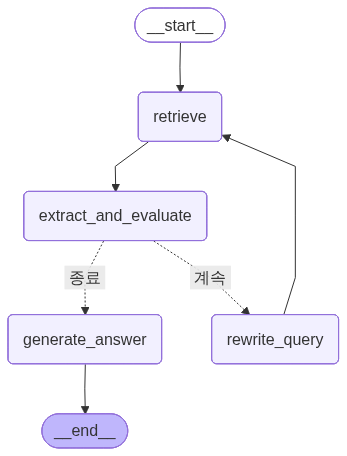

In [42]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# 그래프 생성
workflow = StateGraph(PersonalRagState)

# 노드 추가
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("extract_and_evaluate", extract_and_evaluate_information)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_answer", generate_node_answer)


# 엣지 추가
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "extract_and_evaluate")

# 조건부 엣지 추가
workflow.add_conditional_edges(
    "extract_and_evaluate",
    should_continue,
    {
        "계속": "rewrite_query",
        "종료": "generate_answer"
    }
)
workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("generate_answer", END)

# 그래프 컴파일
personal_law_agent = workflow.compile()

# 그래프 시각화
display(Image(personal_law_agent.get_graph().draw_mermaid_png()))

In [43]:
inputs = {"question": "개인정보 처리에 대한 동의를 받을 때 주의해야 할 점은 무엇인가요?"}
for output in personal_law_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

---문서 검색---
"Node 'retrieve':"
("Value: {'documents': [Document(id='c3ca1cd5-b6cb-4645-a3ae-d8f08245e734', "
 "metadata={'source': 'data/개인정보 "
 "보호법(법률)(제19234호)(20240315).pdf', 'name': '개인정보 보호법', 'chapter': "
 "'제3장 개인정보의 처리\\n         제1절 개인정보의 수집, 이용, 제공 등'}, page_content='[법률정보]\\n다음 "
 '조항은 개인정보 보호법 제3장 개인정보의 처리\\n         제1절 개인정보의 수집, 이용, 제공 등에서 발췌한 '
 '내용입니다.\\n\\n[법률조항]\\n제22조(동의를 받는 방법) ① 개인정보처리자는 이 법에 따른 개인정보의 처리에 대하여 '
 '정보주체(제22조의2제1항에\\n따른 법정대리인을 포함한다. 이하 이 조에서 같다)의 동의를 받을 때에는 각각의 동의 사항을 구분하여 '
 '정보주체가\\n이를 명확하게 인지할 수 있도록 알리고 동의를 받아야 한다. 이 경우 다음 각 호의 경우에는 동의 사항을 구분하여\\n각각 '
 '동의를 받아야 한다. <개정 2017. 4. 18., 2023. 3. 14.>\\n1. 제15조제1항제1호에 따라 동의를 받는 '
 '경우\\n2. 제17조제1항제1호에 따라 동의를 받는 경우\\n3. 제18조제2항제1호에 따라 동의를 받는 경우\\n4. 제19조제1호에 '
 '따라 동의를 받는 경우\\n5. 제23조제1항제1호에 따라 동의를 받는 경우\\n6. 제24조제1항제1호에 따라 동의를 받는 '
 '경우\\n7. 재화나 서비스를 홍보하거나 판매를 권유하기 위하여 개인정보의 처리에 대한 동의를 받으려는 경우\\n8. 그 밖에 정보주체를 '
 '보호하기 위하여 동의 사항을 구분하여 동의를 받아야 할 필요가 있는 경우로서 대통령령으\\n로 정하는 경우\\n② 개인정보처리자는 '

In [44]:
print(value['node_answer'])

# 개인정보 처리에 대한 동의를 받을 때 주의해야 할 점

## 1. 직접적인 답변
개인정보 처리에 대한 동의를 받을 때는 각 동의 사항을 명확히 구분하여 정보주체가 이해할 수 있도록 알리고, 서면으로 동의를 받을 경우 개인정보의 수집 및 이용 목적과 항목을 명확히 표시해야 합니다. 또한, 선택적으로 동의할 수 있는 사항에 대해 동의하지 않는 이유로 서비스 제공을 거부할 수 없습니다.

## 2. 관련 법률 조항 및 해석
- **개인정보 보호법 제22조**에 따르면, 개인정보처리자는 동의를 받을 때 각각의 동의 사항을 구분하여 정보주체가 명확하게 인지할 수 있도록 알리고 동의를 받아야 합니다. 이는 정보주체를 보호하기 위한 조치입니다.
- 또한, 서면으로 동의를 받을 때는 개인정보의 수집 및 이용 목적과 항목 등을 명확히 표시해야 하며, 정보주체가 선택적으로 동의할 수 있는 사항에 대해 동의하지 않는 이유로 서비스 제공을 거부할 수 없다는 점도 명시되어 있습니다.
- 개인정보처리자는 동의 없이 처리할 수 있는 개인정보에 대해서는 그 항목과 법적 근거를 정보주체에게 알려야 합니다 (출처: [개인정보 보호법 제22조](https://law.go.kr/법령/개인정보보호법/제22조)).

## 3. 추가 설명 또는 예시
예를 들어, 온라인 쇼핑몰에서 회원가입을 할 때, 개인정보 수집에 대한 동의를 받을 경우, '이름', '주소', '전화번호'와 같은 항목을 각각 구분하여 설명하고, 각 항목의 수집 목적을 명확히 해야 합니다. 또한, '마케팅 정보 수신 동의'와 같은 선택적 동의 사항에 대해 동의하지 않는다고 해서 회원가입이 불가능하게 해서는 안 됩니다.

## 4. 결론 및 요약
개인정보 처리에 대한 동의를 받을 때는 정보주체가 각 동의 사항을 명확히 이해할 수 있도록 구분하여 알리고, 서면으로 동의를 받을 경우 수집 목적과 항목을 명확히 해야 합니다. 선택적 동의 사항에 대해 동의하지 않는 이유로 서비스 제공을 거부할 수 없으며, 동의 없이 처리할 수 있는 개인정보

`(2) 근로기준법 RAG 에이전트`

In [45]:
# 근로기준법
class LaborRagState(CorrectiveRagState):
    rewritten_query: str   # 재작성한 질문
    extracted_info: Optional[ExtractedInformation]   # 추출된 정보 조각
    node_answer: Optional[str]

In [46]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal

def retrieve_documents(state: LaborRagState) -> LaborRagState:
    print("---문서 검색---")
    query = state.get("rewritten_query", state["question"])
    docs = labor_law_search.invoke(query)
    return {"documents": docs}

def extract_and_evaluate_information(state: LaborRagState) -> LaborRagState:
    print("---정보 추출 및 평가---")
    extracted_strips = []

    for doc in state["documents"]:
        extract_prompt = ChatPromptTemplate.from_messages([
            ("system", """당신은 근로기준법 전문가입니다. 주어진 문서에서 질문과 관련된 주요 사실과 정보를 3~5개 정도 추출하세요.
            각 추출된 정보에 대해 다음 두 가지 측면을 0에서 1 사이의 점수로 평가하세요:
            1. 질문과의 관련성
            2. 답변의 충실성 (질문에 대한 완전하고 정확한 답변을 제공할 수 있는 정도)

            추출 형식:
            1. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            2. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            ...

            마지막으로, 추출된 정보를 종합하여 질문에 대한 전반적인 답변 가능성을 0에서 1 사이의 점수로 평가하세요."""),
            ("human", "[질문]\n{question}\n\n[문서 내용]\n{document_content}")
        ])

        extract_llm = llm.with_structured_output(ExtractedInformation)

        extracted_data = extract_llm.invoke(extract_prompt.format(
            question=state["question"],
            document_content=doc.page_content
        ))

        if extracted_data.query_relevance < 0.8:
            continue

        for strip in extracted_data.strips:
            if strip.relevance_score > 0.7 and strip.faithfulness_score > 0.7:
                extracted_strips.append(strip)

    return {
        "extracted_info": extracted_strips,
        "num_generations": state.get("num_generations", 0) + 1
    }

def rewrite_query(state: LaborRagState) -> LaborRagState:
    print("---쿼리 재작성---")

    rewrite_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 근로기준법 전문가입니다. 주어진 원래 질문과 추출된 정보를 바탕으로, 더 관련성 있고 충실한 정보를 찾기 위해 검색 쿼리를 개선해주세요.

        다음 사항을 고려하여 검색 쿼리를 개선하세요:
        1. 원래 질문의 핵심 요소
        2. 추출된 정보의 관련성 점수
        3. 추출된 정보의 충실성 점수
        4. 부족한 정보나 더 자세히 알아야 할 부분

        개선된 검색 쿼리 작성 단계:
        1. 2-3개의 검색 쿼리를 제안하세요.
        2. 각 쿼리는 구체적이고 간결해야 합니다(5-10 단어 사이).
        3. 근로기준법과 관련된 전문 용어를 적절히 활용하세요.
        4. 각 쿼리 뒤에는 해당 쿼리를 제안한 이유를 간단히 설명하세요.

        출력 형식:
        1. [개선된 검색 쿼리 1]
        - 이유: [이 쿼리를 제안한 이유 설명]
        2. [개선된 검색 쿼리 2]
        - 이유: [이 쿼리를 제안한 이유 설명]
        3. [개선된 검색 쿼리 3]
        - 이유: [이 쿼리를 제안한 이유 설명]

        마지막으로, 제안된 쿼리 중 가장 효과적일 것 같은 쿼리를 선택하고 그 이유를 설명하세요."""),
        ("human", "원래 질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 개선된 검색 쿼리를 작성해주세요.")
    ])

    extracted_info_str = "\n".join([strip.content for strip in state["extracted_info"]])

    rewrite_llm = llm.with_structured_output(RefinedQuestion)

    response = rewrite_llm.invoke(rewrite_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))

    return {"rewritten_query": response.question_refined}

def generate_node_answer(state: LaborRagState) -> LaborRagState:
    print("---답변 생성---")

    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 근로기준법 전문가입니다. 주어진 질문과 추출된 정보를 바탕으로 답변을 생성해주세요.
        답변은 마크다운 형식으로 작성하며, 각 정보의 출처를 명확히 표시해야 합니다.
        답변 구조:
        1. 질문에 대한 직접적인 답변
        2. 관련 법률 조항 및 해석
        3. 추가 설명 또는 예시 (필요한 경우)
        4. 결론 및 요약
        각 섹션에서 사용된 정보의 출처를 괄호 안에 명시하세요. 예: (출처: 근로기준법 제15조)"""),
        ("human", "질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 최종 답변을 작성해주세요.")
    ])

    extracted_info_str = "\n".join([f"내용: {strip.content}\n출처: {strip.source}\n관련성: {strip.relevance_score}\n충실성: {strip.faithfulness_score}" for strip in state["extracted_info"]])

    node_answer = llm.invoke(answer_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))

    return {"node_answer": node_answer.content}

def should_continue(state: LaborRagState) -> Literal["계속", "종료"]:
    if state["num_generations"] >= 2:
        return "종료"
    if len(state["extracted_info"]) >= 1:
        return "종료"
    return "계속"

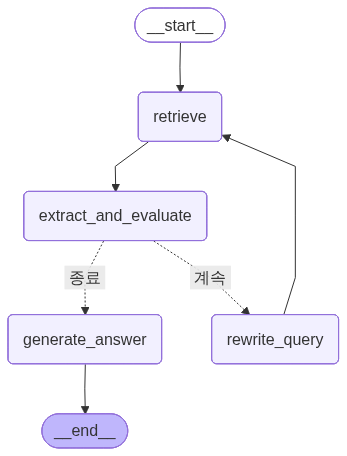

In [47]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# 그래프 생성
workflow = StateGraph(LaborRagState)

# 노드 추가
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("extract_and_evaluate", extract_and_evaluate_information)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_answer", generate_node_answer)


# 엣지 추가
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "extract_and_evaluate")

# 조건부 엣지 추가
workflow.add_conditional_edges(
    "extract_and_evaluate",
    should_continue,
    {
        "계속": "rewrite_query",
        "종료": "generate_answer"
    }
)
workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("generate_answer", END)

# 그래프 컴파일
labor_law_agent = workflow.compile()

# 그래프 시각화
display(Image(labor_law_agent.get_graph().draw_mermaid_png()))

In [48]:
inputs = {"question": "근로계약 체결할 때 주의해야 할 점은 무엇인가요?"}
for output in labor_law_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

---문서 검색---


"Node 'retrieve':"
("Value: {'documents': [Document(id='4651dcff-0eac-4262-a373-bad218ea88d0', "
 "metadata={'chapter': '제5장 여성과 소년', 'name': '근로기준법', 'source': "
 "'data/근로기준법(법률)(제18176호)(20211119).pdf'}, "
 "page_content='[법률정보]\\n다음 조항은 근로기준법 제5장 여성과 소년에서 발췌한 "
 '내용입니다.\\n\\n[법률조항]\\n제67조(근로계약) ① 친권자나 후견인은 미성년자의 근로계약을 대리할 수 없다.\\n② 친권자, '
 '후견인 또는 고용노동부장관은 근로계약이 미성년자에게 불리하다고 인정하는 경우에는 이를 해지할 수\\n있다.<개정 2010. 6. '
 '4.>\\n③ 사용자는 18세 미만인 사람과 근로계약을 체결하는 경우에는 제17조에 따른 근로조건을 서면(「전자문서 및 전\\n자거래 '
 '기본법」 제2조제1호에 따른 전자문서를 포함한다)으로 명시하여 교부하여야 한다.<신설 2007. 7. 27., 2020.\\n5. '
 "26., 2021. 1. 5.>'), Document(id='eb260379-0ad8-41b7-951b-ec622871c3ce', "
 "metadata={'name': '근로기준법', 'source': "
 "'data/근로기준법(법률)(제18176호)(20211119).pdf', 'chapter': '제9장 "
 "취업규칙'}, page_content='[법률정보]\\n다음 조항은 근로기준법 제9장 취업규칙에서 발췌한 "
 '내용입니다.\\n\\n[법률조항]\\n제93조(취업규칙의 작성ㆍ신고) 상시 10명 이상의 근로자를 사용하는 사용자는 다음 각 호의 사항에 '
 '관한 취업규칙을\\n작성하여 고용노동부장관에게 신고하여야 한다. 이를

In [49]:
print(value['node_answer'])

# 근로계약 체결 시 주의해야 할 점

## 1. 직접적인 답변
근로계약을 체결할 때 주의해야 할 점은 다음과 같습니다:
- 18세 미만의 근로자와 계약을 체결할 경우, 근로조건을 서면으로 명시해야 합니다.
- 미성년자의 근로계약은 친권자나 후견인이 대리할 수 없습니다.
- 취업규칙을 작성하고 신고해야 하며, 이는 상시 10명 이상의 근로자를 사용하는 사업장에서 요구됩니다.
- 근로자의 권리와 의무, 퇴직 및 안전과 보건에 관한 사항을 명확히 해야 합니다.

## 2. 관련 법률 조항 및 해석
- **근로기준법 제67조**: 18세 미만인 사람과의 근로계약 체결 시 근로조건을 서면으로 명시해야 하며, 친권자나 후견인은 미성년자의 근로계약을 대리할 수 없습니다.
- **근로기준법 제9장**: 취업규칙의 작성 및 신고가 필요하며, 취업규칙에는 업무의 시작과 종료 시각, 휴게시간, 휴일, 임금의 결정 및 지급 방법 등 근로조건에 관한 중요한 사항들이 포함되어야 합니다. 또한, 근로자의 권리와 의무, 퇴직에 관한 사항, 안전과 보건에 관한 사항도 명확히 해야 합니다.

## 3. 추가 설명 또는 예시
예를 들어, 만약 17세의 청소년을 고용하고자 할 경우, 고용주는 반드시 근로계약서에 근로조건을 서면으로 명시해야 하며, 이 계약은 청소년의 친권자나 후견인이 대리할 수 없으므로, 청소년 본인이 직접 계약을 체결해야 합니다. 또한, 사업장에서 10명 이상의 근로자를 고용하는 경우, 취업규칙을 작성하고 이를 근로자에게 공지해야 합니다.

## 4. 결론 및 요약
근로계약 체결 시에는 미성년자의 근로조건을 서면으로 명시하고, 취업규칙을 작성 및 신고하는 것이 필수적입니다. 또한, 근로자의 권리와 의무를 명확히 하는 것이 중요합니다. 이러한 사항들을 준수하지 않을 경우 법적 문제가 발생할 수 있으므로, 주의가 필요합니다. (출처: 근로기준법 제67조, 근로기준법 제9장)


`(3) 주택임대차보호법 RAG 에이전트`

In [50]:
# 주택임대차보호법
class HousingRagState(CorrectiveRagState):
    rewritten_query: str   # 재작성한 질문
    extracted_info: Optional[ExtractedInformation]   # 추출된 정보 조각
    node_answer: Optional[str]

In [51]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal

def retrieve_documents(state: HousingRagState) -> HousingRagState:
    print("---문서 검색---")
    query = state.get("rewritten_query", state["question"])
    docs = housing_law_search.invoke(query)
    return {"documents": docs}

def extract_and_evaluate_information(state: HousingRagState) -> HousingRagState:
    print("---정보 추출 및 평가---")
    extracted_strips = []

    for doc in state["documents"]:
        extract_prompt = ChatPromptTemplate.from_messages([
            ("system", """당신은 주택임대차보호법 전문가입니다. 주어진 문서에서 질문과 관련된 주요 사실과 정보를 3~5개 정도 추출하세요.
            각 추출된 정보에 대해 다음 두 가지 측면을 0에서 1 사이의 점수로 평가하세요:
            1. 질문과의 관련성
            2. 답변의 충실성 (질문에 대한 완전하고 정확한 답변을 제공할 수 있는 정도)

            추출 형식:
            1. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            2. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            ...

            마지막으로, 추출된 정보를 종합하여 질문에 대한 전반적인 답변 가능성을 0에서 1 사이의 점수로 평가하세요."""),
            ("human", "[질문]\n{question}\n\n[문서 내용]\n{document_content}")
        ])

        extract_llm = llm.with_structured_output(ExtractedInformation)

        extracted_data = extract_llm.invoke(extract_prompt.format(
            question=state["question"],
            document_content=doc.page_content
        ))

        if extracted_data.query_relevance < 0.8:
            continue

        for strip in extracted_data.strips:
            if strip.relevance_score > 0.7 and strip.faithfulness_score > 0.7:
                extracted_strips.append(strip)

    return {
        "extracted_info": extracted_strips,
        "num_generations": state.get("num_generations", 0) + 1
    }

def rewrite_query(state: HousingRagState) -> HousingRagState:
    print("---쿼리 재작성---")

    rewrite_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 주택임대차보호법 전문가입니다. 주어진 원래 질문과 추출된 정보를 바탕으로, 더 관련성 있고 충실한 정보를 찾기 위해 검색 쿼리를 개선해주세요.

        다음 사항을 고려하여 검색 쿼리를 개선하세요:
        1. 원래 질문의 핵심 요소
        2. 추출된 정보의 관련성 점수
        3. 추출된 정보의 충실성 점수
        4. 부족한 정보나 더 자세히 알아야 할 부분

        개선된 검색 쿼리 작성 단계:
        1. 2-3개의 검색 쿼리를 제안하세요.
        2. 각 쿼리는 구체적이고 간결해야 합니다(5-10 단어 사이).
        3. 주택임대차보호법과 관련된 전문 용어를 적절히 활용하세요.
        4. 각 쿼리 뒤에는 해당 쿼리를 제안한 이유를 간단히 설명하세요.

        출력 형식:
        1. [개선된 검색 쿼리 1]
        - 이유: [이 쿼리를 제안한 이유 설명]
        2. [개선된 검색 쿼리 2]
        - 이유: [이 쿼리를 제안한 이유 설명]
        3. [개선된 검색 쿼리 3]
        - 이유: [이 쿼리를 제안한 이유 설명]

        마지막으로, 제안된 쿼리 중 가장 효과적일 것 같은 쿼리를 선택하고 그 이유를 설명하세요."""),
        ("human", "원래 질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 개선된 검색 쿼리를 작성해주세요.")
    ])

    extracted_info_str = "\n".join([strip.content for strip in state["extracted_info"]])

    rewrite_llm = llm.with_structured_output(RefinedQuestion)

    response = rewrite_llm.invoke(rewrite_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))

    return {"rewritten_query": response.question_refined}

def generate_node_answer(state: HousingRagState) -> HousingRagState:
    print("---답변 생성---")

    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 주택임대차보호법 전문가입니다. 주어진 질문과 추출된 정보를 바탕으로 답변을 생성해주세요.
        답변은 마크다운 형식으로 작성하며, 각 정보의 출처를 명확히 표시해야 합니다.
        답변 구조:
        1. 질문에 대한 직접적인 답변
        2. 관련 법률 조항 및 해석
        3. 추가 설명 또는 예시 (필요한 경우)
        4. 결론 및 요약
        각 섹션에서 사용된 정보의 출처를 괄호 안에 명시하세요. 예: (출처: 주택임대차보호법 제15조)"""),
        ("human", "질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 최종 답변을 작성해주세요.")
    ])

    extracted_info_str = "\n".join([f"내용: {strip.content}\n출처: {strip.source}\n관련성: {strip.relevance_score}\n충실성: {strip.faithfulness_score}" for strip in state["extracted_info"]])

    node_answer = llm.invoke(answer_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))

    return {"node_answer": node_answer.content}

def should_continue(state: HousingRagState) -> Literal["계속", "종료"]:
    if state["num_generations"] >= 2:
        return "종료"
    if len(state["extracted_info"]) >= 1:
        return "종료"
    return "계속"

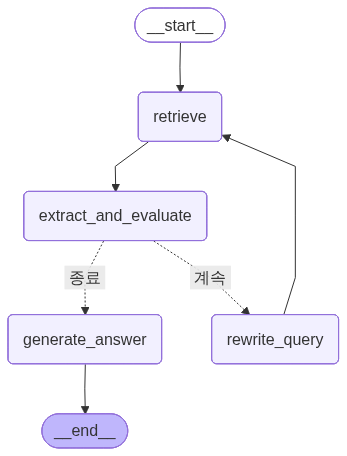

In [52]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# 그래프 생성
workflow = StateGraph(HousingRagState)

# 노드 추가
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("extract_and_evaluate", extract_and_evaluate_information)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_answer", generate_node_answer)


# 엣지 추가
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "extract_and_evaluate")

# 조건부 엣지 추가
workflow.add_conditional_edges(
    "extract_and_evaluate",
    should_continue,
    {
        "계속": "rewrite_query",
        "종료": "generate_answer"
    }
)
workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("generate_answer", END)

# 그래프 컴파일
housing_law_agent = workflow.compile()

# 그래프 시각화
display(Image(housing_law_agent.get_graph().draw_mermaid_png()))

In [53]:
inputs = {"question": "대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?"}
for output in housing_law_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

---문서 검색---
"Node 'retrieve':"
("Value: {'documents': [Document(id='d3759bbd-e089-408a-af3f-ff8f4f5863bc', "
 "metadata={'source': "
 "'data/주택임대차보호법(법률)(제19356호)(20230719).pdf', 'name': "
 "'주택임대차보호법'}, page_content='[법률정보]\\n다음 조항은 주택임대차보호법에서 "
 '발췌한 내용입니다.\\n\\n[법률조항]\\n제3조의7(임대인의 정보 제시 의무) 임대차계약을 체결할 때 임대인은 다음 각 호의 사항을 '
 '임차인에게 제시하여야 한\\n다.\\n1. 제3조의6제3항에 따른 해당 주택의 확정일자 부여일, 차임 및 보증금 등 정보. 다만, '
 '임대인이 임대차계약을 체결\\n하기 전에 제3조의6제4항에 따라 동의함으로써 이를 갈음할 수 있다.\\n2. 「국세징수법」 제108조에 '
 '따른 납세증명서 및 「지방세징수법」 제5조제2항에 따른 납세증명서. 다만, 임대인이 임\\n대차계약을 체결하기 전에 「국세징수법」 '
 '제109조제1항에 따른 미납국세와 체납액의 열람 및 「지방세징수법」 제\\n6조제1항에 따른 미납지방세의 열람에 각각 동의함으로써 이를 '
 "갈음할 수 있다.\\n[본조신설 2023. 4. 18.]'), "
 "Document(id='fdf66977-4c58-4d49-b3a6-6e25e55f8358', metadata={'source': "
 "'data/주택임대차보호법(법률)(제19356호)(20230719).pdf', 'name': "
 "'주택임대차보호법'}, page_content='[법률정보]\\n다음 조항은 주택임대차보호법에서 "
 '발췌한 내용입니다.\\n\\n[법률조항]\\n제3조의7(임대인의 정보 제시 의무) 임대차계

In [54]:
print(value['node_answer'])

# 대리인과 아파트 임대차 계약 체결 시 주의사항

## 1. 직접적인 답변
대리인을 통해 아파트 임대차 계약을 체결할 때는 임대인이 제공해야 할 법적 정보를 정확히 전달받는 것이 중요합니다. 특히, 주택의 확정일자, 차임, 보증금 등의 정보를 반드시 확인해야 합니다.

## 2. 관련 법률 조항 및 해석
임대인은 임대차계약을 체결할 때 임차인에게 해당 주택의 확정일자 부여일, 차임 및 보증금 등의 정보를 제시해야 하며, 이를 위반할 경우 법적 책임을 질 수 있습니다 (출처: 법률정보). 또한, 임대인은 납세증명서를 임차인에게 제시해야 하며, 미납국세와 체납액의 열람에 동의함으로써 이를 갈음할 수 있습니다 (출처: 법률정보).

## 3. 추가 설명 또는 예시
대리인을 통해 계약을 진행할 경우, 대리인이 임대인의 정보를 정확히 전달해야 하며, 임대인이 제공해야 하는 정보에는 주택의 확정일자, 차임, 보증금 등이 포함됩니다 (출처: 법률정보). 예를 들어, 대리인이 임대인의 납세증명서를 임차인에게 제시하지 않으면, 임차인은 계약 체결 후 법적 문제에 직면할 수 있습니다.

## 4. 결론 및 요약
대리인과 아파트 임대차 계약을 체결할 때는 임대인이 제공해야 할 법적 정보를 철저히 확인하는 것이 필수적입니다. 임대인의 정보 제공 의무를 준수하지 않을 경우 법적 문제가 발생할 수 있으므로, 대리인을 통해 계약을 진행할 때는 특히 주의가 필요합니다 (출처: 법률정보).


`(4) 웹 검색 기반 RAG 에이전트`

In [55]:
# 웹 검색 도구
class SearchRagState(CorrectiveRagState):
    rewritten_query: str   # 재작성한 질문
    extracted_info: Optional[ExtractedInformation]   # 추출된 정보 조각
    node_answer: Optional[str]

In [56]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal

def retrieve_documents(state: SearchRagState) -> SearchRagState:
    print("---문서 검색---")
    query = state.get("rewritten_query", state["question"])
    docs = web_search.invoke(query)
    return {"documents": docs}

def extract_and_evaluate_information(state: SearchRagState) -> SearchRagState:
    print("---정보 추출 및 평가---")
    extracted_strips = []

    for doc in state["documents"]:
        extract_prompt = ChatPromptTemplate.from_messages([
            ("system", """당신은 인터넷 정보 검색 전문가입니다. 주어진 문서에서 질문과 관련된 주요 사실과 정보를 3~5개 정도 추출하세요.
            각 추출된 정보에 대해 다음 두 가지 측면을 0에서 1 사이의 점수로 평가하세요:
            1. 질문과의 관련성
            2. 답변의 충실성 (질문에 대한 완전하고 정확한 답변을 제공할 수 있는 정도)

            추출 형식:
            1. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            2. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            ...

            마지막으로, 추출된 정보를 종합하여 질문에 대한 전반적인 답변 가능성을 0에서 1 사이의 점수로 평가하세요."""),
            ("human", "[질문]\n{question}\n\n[문서 내용]\n{document_content}")
        ])

        extract_llm = llm.with_structured_output(ExtractedInformation)

        extracted_data = extract_llm.invoke(extract_prompt.format(
            question=state["question"],
            document_content=doc.page_content
        ))

        if extracted_data.query_relevance < 0.8:
            continue

        for strip in extracted_data.strips:
            if strip.relevance_score > 0.7 and strip.faithfulness_score > 0.7:
                extracted_strips.append(strip)

    return {
        "extracted_info": extracted_strips,
        "num_generations": state.get("num_generations", 0) + 1
    }

def rewrite_query(state: SearchRagState) -> SearchRagState:
    print("---쿼리 재작성---")

    rewrite_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 인터넷 정보 검색 전문가입니다. 주어진 원래 질문과 추출된 정보를 바탕으로, 더 관련성 있고 충실한 정보를 찾기 위해 검색 쿼리를 개선해주세요.

        다음 사항을 고려하여 검색 쿼리를 개선하세요:
        1. 원래 질문의 핵심 요소
        2. 추출된 정보의 관련성 점수
        3. 추출된 정보의 충실성 점수
        4. 부족한 정보나 더 자세히 알아야 할 부분

        개선된 검색 쿼리 작성 단계:
        1. 2-3개의 검색 쿼리를 제안하세요.
        2. 각 쿼리는 구체적이고 간결해야 합니다(5-10 단어 사이).
        3. 질문과 관련된 전문 용어를 적절히 활용하세요.
        4. 각 쿼리 뒤에는 해당 쿼리를 제안한 이유를 간단히 설명하세요.

        출력 형식:
        1. [개선된 검색 쿼리 1]
        - 이유: [이 쿼리를 제안한 이유 설명]
        2. [개선된 검색 쿼리 2]
        - 이유: [이 쿼리를 제안한 이유 설명]
        3. [개선된 검색 쿼리 3]
        - 이유: [이 쿼리를 제안한 이유 설명]

        마지막으로, 제안된 쿼리 중 가장 효과적일 것 같은 쿼리를 선택하고 그 이유를 설명하세요."""),
        ("human", "원래 질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 개선된 검색 쿼리를 작성해주세요.")
    ])

    extracted_info_str = "\n".join([strip.content for strip in state["extracted_info"]])

    rewrite_llm = llm.with_structured_output(RefinedQuestion)

    response = rewrite_llm.invoke(rewrite_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))

    return {"rewritten_query": response.question_refined}

def generate_node_answer(state: SearchRagState) -> SearchRagState:
    print("---답변 생성---")

    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 인터넷 정보 검색 전문가입니다. 주어진 질문과 추출된 정보를 바탕으로 답변을 생성해주세요.
        답변은 마크다운 형식으로 작성하며, 각 정보의 출처를 명확히 표시해야 합니다.
        답변 구조:
        1. 질문에 대한 직접적인 답변
        2. 관련 출처 및 링크
        3. 추가 설명 또는 예시 (필요한 경우)
        4. 결론 및 요약
        각 섹션에서 사용된 정보의 출처를 괄호 안에 명시하세요. 예: (출처: 블로그 (www.blog.com/page/001)"""),
        ("human", "질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 최종 답변을 작성해주세요.")
    ])

    extracted_info_str = "\n".join([f"내용: {strip.content}\n출처: {strip.source}\n관련성: {strip.relevance_score}\n충실성: {strip.faithfulness_score}" for strip in state["extracted_info"]])

    node_answer = llm.invoke(answer_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))

    return {"node_answer": node_answer.content}

def should_continue(state: SearchRagState) -> Literal["계속", "종료"]:
    if state["num_generations"] >= 2:
        return "종료"
    if len(state["extracted_info"]) >= 1:
        return "종료"
    return "계속"

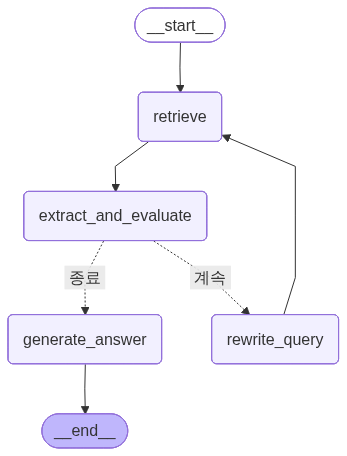

In [57]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# 그래프 생성
workflow = StateGraph(SearchRagState)

# 노드 추가
workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("extract_and_evaluate", extract_and_evaluate_information)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_answer", generate_node_answer)


# 엣지 추가
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "extract_and_evaluate")

# 조건부 엣지 추가
workflow.add_conditional_edges(
    "extract_and_evaluate",
    should_continue,
    {
        "계속": "rewrite_query",
        "종료": "generate_answer"
    }
)
workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("generate_answer", END)

# 그래프 컴파일
search_web_agent = workflow.compile()

# 그래프 시각화
display(Image(search_web_agent.get_graph().draw_mermaid_png()))

In [58]:
inputs = {"question": "대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?"}
for output in search_web_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

---문서 검색---
"Node 'retrieve':"
("Value: {'documents': [Document(metadata={'source': 'web search', 'url': "
 "'https://www.khug.or.kr/jeonse/web/s03/s030203.jsp'}, "
 "page_content='<Document "
 'href="https://www.khug.or.kr/jeonse/web/s03/s030203.jsp"/>\\n대리인과 계약을 체결하는 '
 '경우 대리인이 해당 주택의 임대차계약을 체결할 수 있는 권한을 정확히 위임받고 있는지 확인해야 해요. 일반적으로 대리인의 위임 '
 "여부는\\n</Document>'), Document(metadata={'source': 'web search', 'url': "
 "'https://m.blog.naver.com/a529793/221638778848'}, page_content='<Document "
 'href="https://m.blog.naver.com/a529793/221638778848"/>\\n우선 지난 시간 *1세대 1주택 '
 '비과세 판단시 주의할 점*에 대해서 참고하시기 바랍니다. 1세대 1주택 비과세 판단시 주의할점에 대해서 알아보는 시간을 갖도록 할 '
 '텐데요.우선 지난 ... 부동산 매매계약을 하거나 임대차 계약을 할 때 당연히 등기상 명의인과 계약을 하는 것이 원칙이고 가장 '
 '안전하지만, 소유자의 사정으로 인해 대리인과 계약을 진행해야 하는 상황이 있는데요. > 소유주가 아닌 대리인과 계약하는 경우 필요서류. '
 '① 본인(소유주) 발급 인감증명서. > 본인(소유주) 발급 인감증명서 확인. 인감증명서는 반드시 본인 발급 인감증명서인지 확인을 해야 '
 '합니다. 본인 발급 시에는 "본인 란"에 동그랗게 표시가 되어 있습니다. 따라서 첨부된 인감증명서를 확인할 때 "본인 란"에 동그라미 및 '
 '체크 표시가 되어 있는지를 확인해야 합니다. 따라

In [59]:
print(value['node_answer'])

# 대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점

대리인과 아파트 임대차 계약을 체결할 때는 다음과 같은 점에 주의해야 합니다:

1. **대리인의 권한 확인**: 대리인이 해당 주택의 임대차 계약을 체결할 수 있는 권한을 정확히 위임받았는지 확인해야 합니다. 이는 서면으로 확인하는 것이 좋습니다. (출처: [한국주택금융공사](https://www.khug.or.kr/jeonse/web/s03/s030203.jsp))

2. **대리인의 신원 및 자격 확인**: 대리인의 신원과 자격을 확인하는 것이 중요합니다. 이를 통해 대리인이 실제로 소유자의 대리인인지 확인할 수 있습니다. (출처: [한국주택금융공사](https://www.khug.or.kr/jeonse/web/s03/s030203.jsp))

3. **임대차 계약서에 권한 명시**: 계약서에 대리인의 권한을 명시하는 것이 필요합니다. 이는 향후 분쟁을 예방하는 데 도움이 됩니다. (출처: [한국주택금융공사](https://www.khug.or.kr/jeonse/web/s03/s030203.jsp))

4. **계약 내용 확인**: 대리인과의 계약 체결 후, 계약 내용을 충분히 이해하고 확인해야 합니다. (출처: [한국주택금융공사](https://www.khug.or.kr/jeonse/web/s03/s030203.jsp))

5. **소유주와의 계약 원칙**: 부동산 매매계약이나 임대차 계약을 할 때는 등기상 명의인과 계약하는 것이 원칙입니다. (출처: [네이버 블로그](https://m.blog.naver.com/a529793/221638778848))

6. **인감증명서 확인**: 대리인과 계약을 진행할 경우, 소유주가 발급한 인감증명서를 확인해야 합니다. (출처: [네이버 블로그](https://m.blog.naver.com/a529793/221638778848))

7. **신분증 확인**: 대리인과 계약 시 소유주와 대리인의 신분증을 확인하여 실제 소유주 및 대리인이 맞는지 확인해야

### 4-2. 질문 라우팅 
- 사용자의 질문을 분석하여 적절한 에이전트를 선택 (Adaptive RAG 적용)

In [60]:
from typing import Annotated
from operator import add

# 메인 그래프 상태 정의
class ResearchAgentState(TypedDict):
    question: str
    answers: Annotated[List[str], add]
    final_answer: str
    datasources: List[str]
    evaluation_report: Optional[dict]
    user_decision: Optional[str]

In [61]:
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

# 라우팅 결정을 위한 데이터 모델
class ToolSelector(BaseModel):
    """Routes the user question to the most appropriate tool."""
    tool: Literal["search_personal", "search_labor", "search_housing", "search_web"] = Field(
        description="Select one of the tools, based on the user's question.",
    )

class ToolSelectors(BaseModel):
    """Select the appropriate tools that are suitable for the user question."""
    tools: List[ToolSelector] = Field(
        description="Select one or more tools, based on the user's question.",
    )

# 구조화된 출력을 위한 LLM 설정
structured_llm_tool_selector = llm.with_structured_output(ToolSelectors)

# 라우팅을 위한 프롬프트 템플릿
system = dedent("""You are an AI assistant specializing in routing user questions to the appropriate tools.
Use the following guidelines:
- For questions specifically about legal provisions or articles of the privacy protection law (개인정보 보호법), use the search_personal tool.
- For questions specifically about legal provisions or articles of the labor law (근로기준법), use the search_labor tool.
- For questions specifically about legal provisions or articles of the housing law (주택임대차보호법), use the search_housing tool.
- For any other information, including questions related to these laws but not directly about specific legal provisions, or for the most up-to-date data, use the search_web tool.
Always choose all of the appropriate tools based on the user's question.
If a question is about a law but doesn't seem to be asking about specific legal provisions, include both the relevant law search tool and the search_web tool.""")

route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

# 질문 라우터 정의
question_tool_router = route_prompt | structured_llm_tool_selector

# 테스트 실행
print(question_tool_router.invoke({"question": "근로계약 체결할 때 개인정보 취급 상의 유의사항은 무엇인가요?"}))
print(question_tool_router.invoke({"question": "법에서 정한 연차휴가 기준을 알려주세요."}))
print(question_tool_router.invoke({"question": "개인정보보호법에서 정한 가명정보의 정의는 무엇인가요?"}))

tools=[ToolSelector(tool='search_personal'), ToolSelector(tool='search_labor'), ToolSelector(tool='search_web')]
tools=[ToolSelector(tool='search_labor'), ToolSelector(tool='search_web')]
tools=[ToolSelector(tool='search_personal'), ToolSelector(tool='search_web')]


In [62]:
# 질문 라우팅 노드
def analyze_question_tool_search(state: ResearchAgentState):
    question = state["question"]
    result = question_tool_router.invoke({"question": question})
    datasources = [tool.tool for tool in result.tools]
    return {"datasources": datasources}


def route_datasources_tool_search(state: ResearchAgentState) -> List[str]:
    datasources = set(state['datasources'])
    valid_sources = {"search_personal", "search_labor", "search_housing", "search_web"}

    if datasources.issubset(valid_sources):
        return list(datasources)

    return list(valid_sources)

In [63]:
# 노드 정의
def personal_rag_node(state: PersonalRagState, input=ResearchAgentState) -> ResearchAgentState:
    print("--- 개인정보보호법 전문가 에이전트 시작 ---")
    question = state["question"]
    answer = personal_law_agent.invoke({"question": question})
    return {"answers": [answer["node_answer"]]}

def labor_rag_node(state: LaborRagState, input=ResearchAgentState) -> ResearchAgentState:
    print("--- 근로기준법 전문가 에이전트 시작 ---")
    question = state["question"]
    answer = labor_law_agent.invoke({"question": question})
    return {"answers": [answer["node_answer"]]}

def housing_rag_node(state: HousingRagState, input=ResearchAgentState) -> ResearchAgentState:
    print("--- 주택임대차보호법 전문가 에이전트 시작 ---")
    question = state["question"]
    answer = housing_law_agent.invoke({"question": question})
    return {"answers": [answer["node_answer"]]}

def web_rag_node(state: SearchRagState, input=ResearchAgentState) -> ResearchAgentState:
    print("--- 인터넷 검색 전문가 에이전트 시작 ---")
    question = state["question"]
    answer = search_web_agent.invoke({"question": question})
    return {"answers": [answer["node_answer"]]}


In [64]:
# 최종 답변 생성 노드
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

# RAG 프롬프트 정의
rag_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an assistant answering questions based on provided documents. Follow these guidelines:

1. Use only information from the given documents.
2. If the document lacks relevant info, say "제공된 정보로는 충분한 답변을 할 수 없습니다."
3. Cite the source of information for each sentence in your answer. Use the following format:
    - For legal articles: "법률명 제X조 Y항"
    - For web sources: "출처 제목 (URL)"
4. Don't speculate or add information not in the documents.
5. Keep answers concise and clear.
6. Omit irrelevant information.
7. If multiple sources provide the same information, cite all relevant sources.
8. If information comes from multiple sources, combine them coherently while citing each source.

Example of citation usage:
"부동산 거래 시 계약서에 거래 금액을 명시해야 합니다 (부동산 거래신고 등에 관한 법률 제3조 1항). 또한, 계약 체결일로부터 30일 이내에 신고해야 합니다 (부동산 거래 신고 안내 블로그, https://example.com/realestate)."
"""
    ),
    ("human", "Answer the following question using these documents:\n\n[Documents]\n{documents}\n\n[Question]\n{question}"),
])

def answer_final(state: ResearchAgentState) -> ResearchAgentState:
    """
    Generate answer using the retrieved_documents
    """
    print("---최종 답변---")
    question = state["question"]
    documents = state.get("answers", [])
    if not isinstance(documents, list):
        documents = [documents]

    # 문서 내용을 문자열로 결합
    documents_text = "\n\n".join(documents)

    # RAG generation
    rag_chain = rag_prompt | llm | StrOutputParser()
    generation = rag_chain.invoke({"documents": documents_text, "question": question})
    return {"final_answer": generation, "question":question}


# LLM Fallback 프롬프트 정의
fallback_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an AI assistant helping with various topics. Follow these guidelines:

1. Provide accurate and helpful information to the best of your ability.
2. Express uncertainty when unsure; avoid speculation.
3. Keep answers concise yet informative.
4. Respond ethically and constructively.
5. Mention reliable general sources when applicable."""),
    ("human", "{question}"),
])

def llm_fallback(state: ResearchAgentState) -> ResearchAgentState:
    """
    Generate answer using the LLM without context
    """
    print("---Fallback 답변---")
    question = state["question"]

    # LLM chain
    llm_chain = fallback_prompt | llm | StrOutputParser()

    generation = llm_chain.invoke({"question": question})
    return {"final_answer": generation, "question":question}

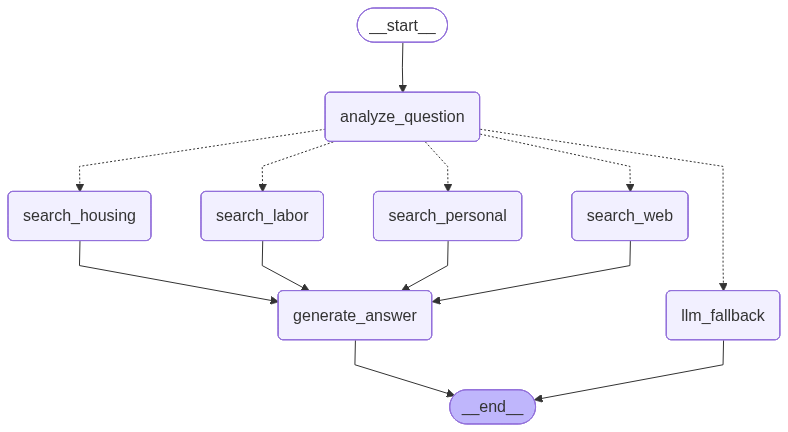

In [65]:
# 노드 정의를 딕셔너리로 관리
nodes = {
    "analyze_question": analyze_question_tool_search,
    "search_personal": personal_rag_node,
    "search_labor": labor_rag_node,
    "search_housing": housing_rag_node,
    "search_web": web_rag_node,
    "generate_answer": answer_final,
    "llm_fallback": llm_fallback
}

# 그래프 생성을 위한 StateGraph 객체를 정의
search_builder = StateGraph(ResearchAgentState)

# 노드 추가
for node_name, node_func in nodes.items():
    search_builder.add_node(node_name, node_func)

# 엣지 추가 (병렬 처리)
search_builder.add_edge(START, "analyze_question")
search_builder.add_conditional_edges(
    "analyze_question",
    route_datasources_tool_search,
    ["search_personal", "search_labor", "search_housing", "search_web", "llm_fallback"]
)

# 검색 노드들을 generate_answer에 연결
for node in ["search_personal", "search_labor", "search_housing", "search_web"]:
    search_builder.add_edge(node, "generate_answer")

search_builder.add_edge("generate_answer", END)
search_builder.add_edge("llm_fallback", END)

# 그래프 컴파일
rag_search_graph = search_builder.compile()

# 그래프 시각화
display(Image(rag_search_graph.get_graph().draw_mermaid_png()))

In [66]:
inputs = {"question": "대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?"}
for output in rag_search_graph.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

"Node 'analyze_question':"
"Value: {'datasources': ['search_housing', 'search_web']}"

----------------------------------------------------------

--- 주택임대차보호법 전문가 에이전트 시작 ---
---문서 검색---
--- 인터넷 검색 전문가 에이전트 시작 ---
---문서 검색---
---정보 추출 및 평가---
---정보 추출 및 평가---
---답변 생성---
---답변 생성---
"Node 'search_housing':"
("Value: {'answers': ['# 대리인과 아파트 임대차 계약 체결 시 주의사항\\n\\n## 1. 직접적인 답변\\n대리인과 "
 '아파트 임대차 계약을 체결할 때는 임대인의 정보 제공 의무를 확인하는 것이 중요합니다. 임대인은 임차인에게 주택의 확정일자 부여일, 차임 '
 '및 보증금 등의 정보를 제시해야 하며, 납세증명서도 제공해야 합니다.\\n\\n## 2. 관련 법률 조항 및 해석\\n임대차계약 체결 시 '
 '임대인의 정보 제공 의무는 법적으로 규정되어 있습니다. 임대인은 임차인에게 해당 주택의 확정일자 부여일, 차임 및 보증금 등의 정보를 '
 '제시해야 하며, 납세증명서를 제시해야 합니다. 미납국세와 체납액의 열람에 동의함으로써 이를 갈음할 수 있습니다 (출처: '
 '법률정보).\\n\\n## 3. 추가 설명 또는 예시\\n임대차계약 체결 전에 임대인이 동의함으로써 정보 제공 의무를 갈음할 수 있는 '
 '조항이 존재합니다. 그러나 이러한 조항이 있을 경우에도 임대인은 법적으로 요구되는 정보를 제공해야 하며, 이를 위반할 경우 법적 문제가 '
 '발생할 수 있습니다. 예를 들어, 임대인이 차임이나 보증금에 대한 정보를 제공하지 않으면 임차인은 계약 체결 후 불이익을 당할 수 '
 '있습니다.\\n\\n## 4. 결론 및 요약\\n대리인과 아파트 임대차 계약을 체결할 때는 임대인의 정보 제공

In [67]:
print(value['final_answer'])

대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 다음과 같습니다:

1. **대리인의 권한 확인**: 대리인이 해당 주택의 임대차 계약을 체결할 수 있는 권한을 정확히 위임받았는지 확인해야 합니다 (출처: [한국주택금융공사](https://www.khug.or.kr/jeonse/web/s03/s030203.jsp)).

2. **서면 위임 확인**: 대리인의 위임 여부는 일반적으로 서면으로 확인하는 것이 좋습니다. 서면 위임장은 향후 분쟁을 예방하는 데 도움이 됩니다 (출처: [한국주택금융공사](https://www.khug.or.kr/jeonse/web/s03/s030203.jsp)).

3. **대리인의 신원 및 자격 확인**: 대리인과의 계약 체결 시, 대리인의 신원 및 자격을 확인하는 것이 중요합니다 (출처: [한국주택금융공사](https://www.khug.or.kr/jeonse/web/s03/s030203.jsp)).

4. **소유주 인감증명서 확인**: 대리인과 계약을 진행할 경우, 소유주가 발급한 인감증명서를 확인해야 합니다. 이는 대리인이 소유주를 대신할 수 있는 정당한 권한을 가지고 있음을 증명하는 문서입니다 (출처: [네이버 블로그](https://m.blog.naver.com/a529793/221638778848)).

5. **신분증 확인**: 대리인과 계약 시 소유주와 대리인의 신분증을 확인하여 실제 소유주 및 대리인이 맞는지 확인해야 합니다 (출처: [네이버 블로그](https://m.blog.naver.com/a529793/221638778848)).

이러한 절차를 통해 계약의 안전성을 높이고, 향후 발생할 수 있는 법적 분쟁을 예방할 수 있습니다.


# 5. 답변 평가 및 확인

### 5-1. 답변을 평가하는 ReAct 에이전트

In [68]:
from textwrap import dedent

evaluation_prompt = dedent("""
당신은 AI 어시스턴트가 생성한 답변을 평가하는 전문가입니다. 주어진 질문과 답변을 평가하고, 60점 만점으로 점수를 매기세요. 다음 기준을 사용하여 평가하십시오:

1. 정확성 (10점)
2. 관련성 (10점)
3. 완전성 (10점)
4. 인용 정확성 (10점)
5. 명확성과 간결성 (10점)
6. 객관성 (10점)

평가 과정:
1. 주어진 질문과 답변을 주의 깊게 읽으십시오.
2. 필요한 경우, 다음 도구를 사용하여 추가 정보를 수집하세요:
   - web_search: 웹 검색
   - personal_law_search: 개인정보보호법 검색
   - labor_law_search: 근로기준법 검색
   - housing_law_search: 주택임대차보호법 검색

   도구 사용 형식:
   Action: [tool_name]
   Action Input: [input for the tool]

3. 각 기준에 대해 1-10점 사이의 점수를 매기세요.
4. 총점을 계산하세요 (60점 만점).

출력 형식:
{
  "scores": {
    "accuracy": 0,
    "relevance": 0,
    "completeness": 0,
    "citation_accuracy": 0,
    "clarity_conciseness": 0,
    "objectivity": 0
  },
  "total_score": 0,
  "brief_evaluation": "간단한 평가 설명"
}

최종 출력에는 각 기준의 점수, 총점, 그리고 간단한 평가 설명만 포함하세요.
""")

In [69]:
tools

[StructuredTool(name='personal_law_search', description='개인정보보호법 법률 조항을 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.personal_law_search'>, func=<function personal_law_search at 0x7cce8ff11dd0>),
 StructuredTool(name='labor_law_search', description='근로기준법 법률 조항을 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.labor_law_search'>, func=<function labor_law_search at 0x7cce8ff11c70>),
 StructuredTool(name='housing_law_search', description='주택임대차보호법 법률 조항을 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.housing_law_search'>, func=<function housing_law_search at 0x7cce8ff11b10>),
 StructuredTool(name='web_search', description='데이터베이스에 없는 정보 또는 최신 정보를 웹에서 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.web_search'>, func=<function web_search at 0x7cce8ff11430>)]

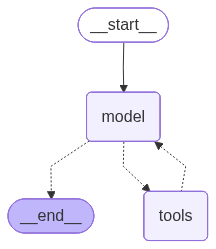

In [70]:
from langchain.agents import create_agent
from IPython.display import Image, display

# 그래프 생성
answer_reviewer = create_agent(
    model=llm,
    tools=tools,
    system_prompt=evaluation_prompt,
    )

# 그래프 출력
display(Image(answer_reviewer.get_graph().draw_mermaid_png()))

In [71]:
# 그래프 실행
from langchain_core.messages import HumanMessage

messages = [HumanMessage(content=f"""[질문]\n{value['question']}\n\n[답변]\n{value['final_answer']}""")]
messages = answer_reviewer.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

[질문]
대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?

[답변]
대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 다음과 같습니다:

1. **대리인의 권한 확인**: 대리인이 해당 주택의 임대차 계약을 체결할 수 있는 권한을 정확히 위임받았는지 확인해야 합니다 (출처: [한국주택금융공사](https://www.khug.or.kr/jeonse/web/s03/s030203.jsp)).

2. **서면 위임 확인**: 대리인의 위임 여부는 일반적으로 서면으로 확인하는 것이 좋습니다. 서면 위임장은 향후 분쟁을 예방하는 데 도움이 됩니다 (출처: [한국주택금융공사](https://www.khug.or.kr/jeonse/web/s03/s030203.jsp)).

3. **대리인의 신원 및 자격 확인**: 대리인과의 계약 체결 시, 대리인의 신원 및 자격을 확인하는 것이 중요합니다 (출처: [한국주택금융공사](https://www.khug.or.kr/jeonse/web/s03/s030203.jsp)).

4. **소유주 인감증명서 확인**: 대리인과 계약을 진행할 경우, 소유주가 발급한 인감증명서를 확인해야 합니다. 이는 대리인이 소유주를 대신할 수 있는 정당한 권한을 가지고 있음을 증명하는 문서입니다 (출처: [네이버 블로그](https://m.blog.naver.com/a529793/221638778848)).

5. **신분증 확인**: 대리인과 계약 시 소유주와 대리인의 신분증을 확인하여 실제 소유주 및 대리인이 맞는지 확인해야 합니다 (출처: [네이버 블로그](https://m.blog.naver.com/a529793/221638778848)).

이러한 절차를 통해 계약의 안전성을 높이고, 향후 발생할 수 있는 법적 분쟁을 예방할 수 있습니다.
===================

In [72]:
json.loads(m.content).keys()

dict_keys(['scores', 'total_score', 'brief_evaluation'])

In [73]:
print(json.loads(m.content)['total_score'])

57


### 5-2. 답변 평가 내용을 확인하는 HITL 추가

In [74]:
# 답변 평가하는 노드를 추가
def evaluate_answer_node(state:ResearchAgentState):
    question = state["question"]
    final_answer = state["final_answer"]

    messages = [HumanMessage(content=f"""[질문]\n{question}\n\n[답변]\n{final_answer}""")]
    response = answer_reviewer.invoke({"messages": messages})
    response_dict = json.loads(response['messages'][-1].content)

    return {"evaluation_report": response_dict, "question": question, "final_answer": final_answer}

# HITL 조건부 엣지 정의
def human_review(state: ResearchAgentState):
    print("\n현재 답변:")
    print(state['final_answer'])
    print("\n평가 결과:")
    print(f"총점: {state['evaluation_report']['total_score']}/60")
    print(state['evaluation_report']['brief_evaluation'])

    user_input = input("\n이 답변을 승인하시겠습니까? (y/n): ").lower()

    if user_input == 'y':
        return "approved"
    else:
        return "rejected"


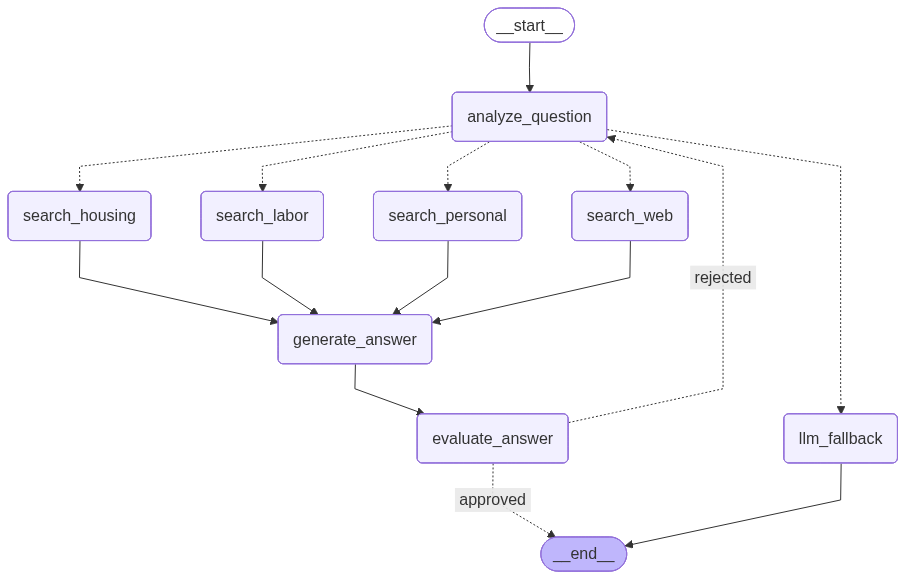

In [75]:
# 노드 정의를 딕셔너리로 관리
nodes = {
    "analyze_question": analyze_question_tool_search,
    "search_personal": personal_rag_node,
    "search_labor": labor_rag_node,
    "search_housing": housing_rag_node,
    "search_web": web_rag_node,
    "generate_answer": answer_final,
    "llm_fallback": llm_fallback,
    "evaluate_answer": evaluate_answer_node,
}

# 그래프 생성을 위한 StateGraph 객체를 정의
search_builder = StateGraph(ResearchAgentState)

# 노드 추가
for node_name, node_func in nodes.items():
    search_builder.add_node(node_name, node_func)

# 엣지 추가 (병렬 처리)
search_builder.add_edge(START, "analyze_question")
search_builder.add_conditional_edges(
    "analyze_question",
    route_datasources_tool_search,
    ["search_personal", "search_labor", "search_housing", "search_web", "llm_fallback"]
)

# 검색 노드들을 generate_answer에 연결
for node in ["search_personal", "search_labor", "search_housing", "search_web"]:
    search_builder.add_edge(node, "generate_answer")

search_builder.add_edge("generate_answer", "evaluate_answer")

# HITL 결과에 따른 조건부 엣지 추가
search_builder.add_conditional_edges(
    "evaluate_answer",
    human_review,
    {
        "approved": END,
        "rejected": "analyze_question"  # 승인되지 않은 경우 질문 분석 단계로 돌아감
    }
)

search_builder.add_edge("llm_fallback", END)

# 그래프 컴파일
legal_rag_agent = search_builder.compile()

# 그래프 시각화
display(Image(legal_rag_agent.get_graph().draw_mermaid_png()))

In [ ]:
inputs = {"question": "대리인과 아파트 임대차 계약을 체결할 때 주의해야 할 점은 무엇인가요?"}
for output in legal_rag_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

"Node 'analyze_question':"
"Value: {'datasources': ['search_housing', 'search_web']}"

----------------------------------------------------------

--- 주택임대차보호법 전문가 에이전트 시작 ---
---문서 검색---
--- 인터넷 검색 전문가 에이전트 시작 ---
---문서 검색---
---정보 추출 및 평가---
---정보 추출 및 평가---
---답변 생성---
---답변 생성---
"Node 'search_housing':"
("Value: {'answers': ['# 대리인과 아파트 임대차 계약 체결 시 주의사항\\n\\n## 1. 직접적인 답변\\n대리인을 "
 '통해 아파트 임대차 계약을 체결할 때는 임대인이 제공해야 할 정보(확정일자, 차임, 보증금 등)를 정확히 확인하고, 대리인이 이 정보를 '
 '올바르게 전달하는지 주의해야 합니다.\\n\\n## 2. 관련 법률 조항 및 해석\\n임대인은 임대차계약을 체결할 때 임차인에게 해당 '
 '주택의 확정일자 부여일, 차임 및 보증금 등의 정보를 제시해야 하며, 이는 법적으로 요구되는 의무입니다. 만약 임대인이 이 정보를 '
 '제공하지 않으면 법적 책임을 질 수 있습니다 (출처: 법률정보).\\n\\n## 3. 추가 설명 또는 예시\\n임대차계약 체결 시 '
 '대리인을 통해 진행할 경우, 대리인은 임대인의 정보를 정확히 전달해야 하며, 임차인은 이러한 정보가 올바른지 확인해야 합니다. 예를 '
 '들어, 대리인이 제공한 차임이나 보증금이 실제 계약서에 기재된 내용과 일치하는지 확인하는 것이 중요합니다. 또한, 임대인은 납세증명서를 '
 '임차인에게 제시해야 하며, 미납국세와 체납액의 열람에 동의함으로써 이를 갈음할 수 있습니다 (출처: 법률정보).\\n\\n## 4. 결론 '
 '및 요약\\n대리인을 통해 아파트 임대차 계약을 체결할 때는 임대인의 정보 제공 의무를 확인하고, 대리

In [ ]:
value

In [ ]:
inputs = {"question": "개인정보 유출 시 기업이 취해야 할 법적 조치는 무엇인가요?"}
for output in legal_rag_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

In [ ]:
value

# 6. Gradio 챗봇

In [1]:
from langgraph.checkpoint.memory import MemorySaver

# HITL 노드로 변경 (그라디오에서 입력을 처리)
def human_review(state: ResearchAgentState):
    pass

# 그래프 생성을 위한 StateGraph 객체를 정의
search_builder = StateGraph(ResearchAgentState)

# 노드 추가
nodes = {
    "analyze_question": analyze_question_tool_search,
    "search_personal": personal_rag_node,
    "search_labor": labor_rag_node,
    "search_housing": housing_rag_node,
    "search_web": web_rag_node,
    "generate_answer": answer_final,
    "llm_fallback": llm_fallback,
    "evaluate_answer": evaluate_answer_node,
    "human_review": human_review,
}

for node_name, node_func in nodes.items():
    search_builder.add_node(node_name, node_func)

# 엣지 추가 (병렬 처리)
search_builder.add_edge(START, "analyze_question")
search_builder.add_conditional_edges(
    "analyze_question",
    route_datasources_tool_search,
    ["search_personal", "search_labor", "search_housing", "search_web", "llm_fallback"]
)

# 검색 노드들을 generate_answer에 연결
for node in ["search_personal", "search_labor", "search_housing", "search_web"]:
    search_builder.add_edge(node, "generate_answer")

search_builder.add_edge("generate_answer", "evaluate_answer")
search_builder.add_edge("evaluate_answer", "human_review")

# HITL 결과에 따른 조건부 엣지 추가
search_builder.add_conditional_edges(
    "human_review",
    lambda x: "approved" if x.get("user_decision") == "approved" else "rejected",
    {
        "approved": END,
        "rejected": "analyze_question"
    }
)

search_builder.add_edge("llm_fallback", END)

# 메모리 추가
memory = MemorySaver()

# 그래프 컴파일 (Breakpoint 설정)
legal_rag_agent = search_builder.compile(checkpointer=memory, interrupt_before=["human_review"])

# 그래프 시각화
display(Image(legal_rag_agent.get_graph().draw_mermaid_png()))

NameError: name 'StateGraph' is not defined

# 

In [ ]:
import gradio as gr
import uuid
from typing import List, Tuple
from langgraph.checkpoint.memory import MemorySaver

# 메모리 사용 준비
memory = MemorySaver()
legal_rag_agent = search_builder.compile(checkpointer=memory, interrupt_before=["human_review"])

# 예시 질문들
example_questions = [
    "사업장에서 CCTV를 설치할 때 주의해야 할 법적 사항은 무엇인가요?",
    "전월세 계약 갱신 요구권의 행사 기간과 조건은 어떻게 되나요?",
    "개인정보 유출 시 기업이 취해야 할 법적 조치는 무엇인가요?",
]

# 챗봇 클래스 생성
class ChatBot:
    def __init__(self):
        self.thread_id = str(uuid.uuid4())
        self.user_decision = False

    def process_message(self, message: str) -> str:
        try:
            config = {"configurable": {"thread_id": self.thread_id}}

            if not self.user_decision:
                # Breakpoint 까지 먼저 실행
                inputs = {"question": message}
                legal_rag_agent.invoke(inputs, config=config)

                # Breakpoint에서 현재 상태를 출력하고, 사용자의 승인 여부를 입력받음
                current_state = legal_rag_agent.get_state(config)
                print("Current state:", current_state)

                final_answer = current_state.values.get("final_answer", "No answer available")
                evaluation_report = current_state.values.get('evaluation_report', {'total_score': 0, 'brief_evaluation': 'No evaluation available'})

                response = f"""현재 답변:
            {final_answer}

            평가 결과:
            총점: {evaluation_report.get('total_score', 0)}/60
            {evaluation_report.get('brief_evaluation', 'No evaluation available')}

            이 답변을 승인하시겠습니까? (y/n): """

                # 사용자 승인 여부를 True로 변경
                self.user_decision = True
                return response

            else:
                # 사용자 입력에 따라 다음 경로를 선택
                user_decision = message.lower()
                if user_decision == 'y':
                    self.user_decision = False # 초기화
                    # 상태 업데이트 - 질문을 수정하여 업데이트
                    legal_rag_agent.update_state(config, {"user_decision": "approved"})
                    # 나머지 작업을 이어서 진행
                    legal_rag_agent.invoke(None, config=config)
                    # 작업이 종료되고 최종 상태의 메시지를 출력
                    current_state = legal_rag_agent.get_state(config)
                    print("Final state:", current_state)
                    return current_state.values.get("final_answer", "No final answer available")
                else:
                    self.user_decision = False # 초기화
                    # 상태 업데이트 - 질문을 수정하여 업데이트
                    legal_rag_agent.update_state(config, {"user_decision": "rejected"})
                    # 나머지 작업을 이어서 진행
                    legal_rag_agent.invoke(None, config=config)
                    # Breakpoint에서 현재 상태를 출력하고, 사용자의 승인 여부를 입력받음
                    current_state = legal_rag_agent.get_state(config)
                    print("Revised state:", current_state)

                    final_answer = current_state.values.get("final_answer", "No answer available")
                    evaluation_report = current_state.values.get('evaluation_report', {'total_score': 0, 'brief_evaluation': 'No evaluation available'})

                    response = f"""다시 생성한 답변:
                {final_answer}

                평가 결과:
                총점: {evaluation_report.get('total_score', 0)}/60
                {evaluation_report.get('brief_evaluation', 'No evaluation available')}

                이 답변을 승인하시겠습니까? (y/n): """

                    # 사용자 승인 여부를 True로 변경
                    self.user_decision = True
                    return response

        except Exception as e:
            print(f"Error occurred: {str(e)}")
            return "죄송합니다. 응답을 생성하는 동안 오류가 발생했습니다. 다시 시도해 주세요."

    def chat(self, message: str, history: List[Tuple[str, str]]) -> str:
        print(f"Thread ID: {self.thread_id}")
        response = self.process_message(message)
        return response

chatbot = ChatBot()

# ChatInterface 생성
demo = gr.ChatInterface(
    fn=chatbot.chat,
    title="생활법률 AI 어시스턴트",
    description="주택임대차보호법, 근로기준법, 개인정보보호법 관련 질문에 답변해 드립니다.",
    examples=example_questions,
    theme=gr.themes.Soft()
)

# Gradio 앱 실행
demo.launch()

Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


Thread ID: 08cdae9c-8ec0-44e7-9458-fd7b40e3d5e1
--- 주택임대차보호법 전문가 에이전트 시작 ---
---문서 검색---
--- 인터넷 검색 전문가 에이전트 시작 ---
---문서 검색---
---정보 추출 및 평가---
---정보 추출 및 평가---
---답변 생성---
---답변 생성---
---최종 답변---
Current state: StateSnapshot(values={'question': '전월세 계약 갱신 요구권의 행사 기간과 조건은 어떻게 되나요?', 'answers': ['# 전월세 계약 갱신 요구권의 행사 기간과 조건\n\n## 1. 직접적인 답변\n전월세 계약 갱신 요구권은 임대차 기간이 끝나기 6개월 전부터 2개월 전까지의 기간에 임대인이 갱신 거절 통지를 하지 않으면 자동으로 계약이 갱신됩니다. 임차인이 계약 갱신을 원하지 않을 경우, 임대차 기간이 끝나기 2개월 전까지 통지해야 합니다.\n\n## 2. 관련 법률 조항 및 해석\n- **임대인의 갱신 거절 통지**: 임대인은 임대차 기간이 끝나기 6개월 전부터 2개월 전까지의 기간에 임차인에게 갱신 거절의 통지를 하지 않으면 계약이 갱신된 것으로 본다. (출처: 주택임대차보호법 제6조 ①)\n- **임차인의 갱신 요구**: 임차인이 임대차 기간이 끝나기 2개월 전까지 통지하지 않으면 계약이 갱신된 것으로 본다. (출처: 주택임대차보호법 제6조 ①)\n- **임대차 존속기간**: 임대차의 존속기간은 기본적으로 2년으로 본다. (출처: 주택임대차보호법 제6조 ②)\n- **계약 해지 통지**: 전월세 계약 갱신 요구권은 임차인이 언제든지 임대인에게 계약 해지를 통지할 수 있는 권리이다. (출처: 주택임대차보호법 제6조의2)\n- **해지 효력 발생**: 계약 해지는 임대인이 통지를 받은 날부터 3개월이 지나면 효력이 발생한다. (출처: 주택임대차보호법 제6조의2)\n\n## 3. 추가 설명 또는 예시\n예를 들어, 임대차 계약이 2023년 12월 31

In [ ]:
demo.close()

Closing server running on port: 7860
